In [1]:
import numpy as np
import xarray as xr
import pandas as pd
import cftime
import calendar
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.path as mpath
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import matplotlib.ticker as mticker
from matplotlib.colors import TwoSlopeNorm
from matplotlib.patches import Rectangle
import matplotlib.dates as mdates
import imageio
import os
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import datetime #import datetime
from glob import glob
from scipy import signal
from check_time import extract_vars
import seaborn as sns

In [2]:
# dask
import dask
import dask.array as da
import distributed
from dask.distributed import Client

client = Client()
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 8
Total threads: 32,Total memory: 35.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:45439,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:33727,Total threads: 4
Dashboard: http://127.0.0.1:35619/status,Memory: 4.38 GiB
Nanny: tcp://127.0.0.1:35017,


In [3]:
#client.close()

In [4]:
# Extracted: SO2, H2SO4, mmr_SULFATE, TROP_P
"""
extract_vars(fld="/nird/datapeak/NS1004K/elihho/NHIST_tropochem_250916/atm/hist",
             vars=["H2SO4", "mmr_SULFATE", "TROP_P"],  
             ystart=1975,
             yend=2014,
             outfld="/nird/datapeak/NS1004K/elihho/output_pinatubo",
             ow=True)
             #client = Client()
"""

'\nextract_vars(fld="/nird/datapeak/NS1004K/elihho/NHIST_tropochem_250916/atm/hist",\n             vars=["H2SO4", "mmr_SULFATE", "TROP_P"],  \n             ystart=1975,\n             yend=2014,\n             outfld="/nird/datapeak/NS1004K/elihho/output_pinatubo",\n             ow=True)\n             #client = Client()\n'

In [5]:
path_atm = "/nird/datapeak/NS1004K/elihho/NHIST_tropochem_250916/atm/hist"
ds_19 = xr.open_mfdataset(f"{path_atm}/NHIST_tropstratchem_f09_tn14_20250917_1975_2014.cam.h0.*.nc", combine="by_coords", parallel=True)

In [6]:
path_atm_22 = "/nird/datapeak/NS1004K/elihho/NHIST_tropstratchem_20251125_pinatubo10Tg22_e01/atm/hist"
ds_22 = xr.open_mfdataset(f"{path_atm_22}/NHIST_tropstratchem_f09_tn14_20251125_Pinatubo10Tg22_01.cam.h0.*.nc", combine="by_coords", parallel=True)

In [7]:
path_atm_19_c =  "/nird/datapeak/NS1004K/elihho/NHIST_tropstratchem_20260116_pinatubo10tg_19_c/atm/hist"
ds_19_c = xr.open_mfdataset(f"{path_atm_19_c}/NHIST_tropstratchem_f09_tn14_20260116_Pinatubo10Tg19_02.cam.h0.*.nc", combine="by_coords", parallel=True)

In [8]:
path_atm_24 = "/nird/datapeak/NS1004K/elihho/NHIST_tropstratchem_20251129_pinatubo17Tg24_e01/atm/hist"
ds_24 = xr.open_mfdataset(f"{path_atm_24}/NHIST_tropstratchem_f09_tn14_20251129_Pinatubo17Tg24_01.cam.h0.*.nc", combine="by_coords", parallel=True)

In [9]:
path_atm_1825 = "/nird/datapeak/NS1004K/elihho/NHIST_tropstratchem_20251204_pinatubo10Tg18_25_e01/atm/hist"
ds_1825 = xr.open_mfdataset(f"{path_atm_1825}/NHIST_tropstratchem_f09_tn14_20251204_Pinatubo10Tg18_25_01.cam.h0.*.nc", combine="by_coords", parallel=True)

In [10]:
path_atm_1825_17tg = "/nird/datapeak/NS1004K/elihho/NHIST_tropstratchem_20251207_pinatubo17Tg18_25_e01/atm/hist"
ds_1825_17tg = xr.open_mfdataset(f"{path_atm_1825_17tg}/NHIST_tropstratchem_f09_tn14_20251207_Pinatubo17Tg18_25_01.cam.h0.*.nc", combine="by_coords", parallel=True)

In [11]:
path_atm_1tg = "/nird/datapeak/NS1004K/elihho/NHIST_tropstratchem_20251210_pinatubo1Tg19_e01/atm/hist"
ds_1tg = xr.open_mfdataset(f"{path_atm_1tg}/NHIST_tropstratchem_f09_tn14_20251210_Pinatubo1Tg19_01.cam.h0.*.nc", combine="by_coords", parallel=True)

In [12]:
path_atm_1pr = "/nird/datapeak/NS1004K/elihho/NHIST_tropstratchem_20251223_pinatubo10Tg_1pr/atm/hist"
ds_1pr = xr.open_mfdataset(f"{path_atm_1pr}/NHIST_tropstratchem_f09_tn14_20251223_Pinatubo10Tg19_1pr.cam.h0.*.nc", combine="by_coords", parallel=True)

In [13]:
path_atm_60tg = "/nird/datapeak/NS1004K/elihho/NHIST_tropstratchem_20260108_pinatubo60Tg19_e01/atm/hist"
ds_60tg = xr.open_mfdataset(f"{path_atm_60tg}/NHIST_tropstratchem_f09_tn14_20260107_Pinatubo60Tg19.cam.h0.*.nc", combine="by_coords", parallel=True)

In [14]:
client.close()

In [15]:
def shift_one_month_back(t):
    if t.month == 1:
        return cftime.DatetimeNoLeap(t.year - 1, 12, t.day, t.hour, t.minute, t.second)
    else:
        return cftime.DatetimeNoLeap(t.year, t.month - 1, t.day, t.hour, t.minute, t.second)

shifted_time = np.array([shift_one_month_back(t) for t in ds_19['time'].values])
ds_19 = ds_19.assign_coords(time=shifted_time)

shifted_time = np.array([shift_one_month_back(t) for t in ds_22['time'].values])
ds_22 = ds_22.assign_coords(time=shifted_time)

shifted_time = np.array([shift_one_month_back(t) for t in ds_19_c['time'].values])
ds_19_c = ds_19_c.assign_coords(time=shifted_time)

shifted_time = np.array([shift_one_month_back(t) for t in ds_24['time'].values])
ds_24 = ds_24.assign_coords(time=shifted_time)

shifted_time = np.array([shift_one_month_back(t) for t in ds_1825['time'].values])
ds_1825 = ds_1825.assign_coords(time=shifted_time)

shifted_time = np.array([shift_one_month_back(t) for t in ds_1825_17tg['time'].values])
ds_1825_17tg = ds_1825_17tg.assign_coords(time=shifted_time)

shifted_time = np.array([shift_one_month_back(t) for t in ds_1tg['time'].values])
ds_1tg = ds_1tg.assign_coords(time=shifted_time)

shifted_time = np.array([shift_one_month_back(t) for t in ds_1pr['time'].values])
ds_1pr = ds_1pr.assign_coords(time=shifted_time)

shifted_time = np.array([shift_one_month_back(t) for t in ds_60tg['time'].values])
ds_60tg = ds_60tg.assign_coords(time=shifted_time)

### Sulfate burden and SO2 concentrations

In [16]:
lat = ds_19["lat"]
weighted_lat = np.cos(np.deg2rad(lat))
lat_22 = ds_22["lat"]
weighted_lat_22 = np.cos(np.deg2rad(lat_22))
lat_19_c = ds_19_c["lat"]
weighted_lat_19_c = np.cos(np.deg2rad(lat_19_c))
lat_24 = ds_24["lat"]
weighted_lat_24 = np.cos(np.deg2rad(lat_24))
lat_1825 = ds_1825["lat"]
weighted_lat_1825 = np.cos(np.deg2rad(lat_1825))
lat_1825_17tg = ds_1825_17tg["lat"]
weighted_lat_1825_17tg = np.cos(np.deg2rad(lat_1825_17tg))
lat_1tg = ds_1tg["lat"]
weighted_lat_1tg = np.cos(np.deg2rad(lat_1tg))
lat_1pr = ds_1pr["lat"]
weighted_lat_1pr = np.cos(np.deg2rad(lat_1pr))
lat_60tg = ds_60tg["lat"]
weighted_lat_60tg = np.cos(np.deg2rad(lat_60tg))

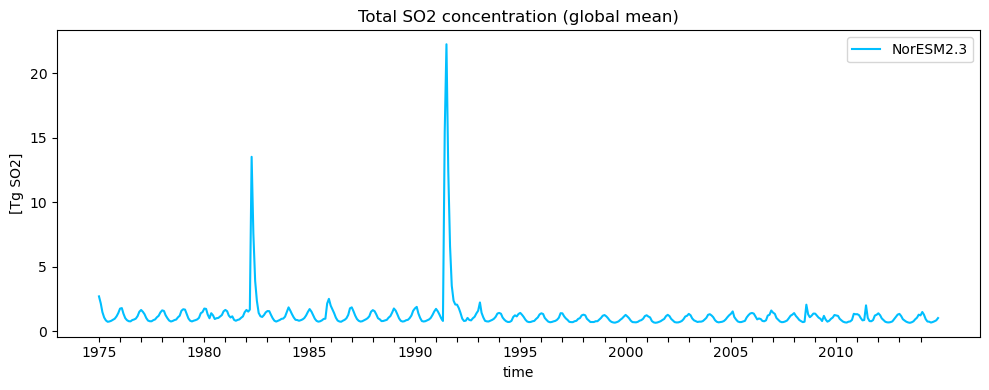

/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/dask/_task_spec.py:764: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/dask/_task_spec.py:764: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/dask/_task_spec.py:764: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/dask/_task_spec.py:764: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/dask/_task_spec.py:764: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/dask/_task_spec.py:764: RuntimeWarn

In [ ]:
M_SO2 = 64.066     
M_air = 28.9647   
m_air_global = 5.3 * 10**21 
K_so2 = (M_SO2 / M_air) * m_air_global *10**(-12)    # mol/mol → Tg conversion factor

lat = ds_19["lat"]
weighted_lat = np.cos(np.deg2rad(lat))
so2 = ds_19["SO2"].weighted(weighted_lat).mean(dim=["lat", "lon", "lev"])

so2_tg = so2 * K_so2

plt.figure(figsize=(10, 4))
so2_tg.plot(color="deepskyblue", label="NorESM2.3")
plt.ylabel("[Tg SO2]")
years = np.arange(1975, 2015)
year_ticks = [cftime.DatetimeNoLeap(int(y), 1, 1) for y in years]
plt.xticks(year_ticks, [str(y) if y % 5 == 0 else '' for y in years])
plt.title("Total SO2 concentration (global mean)")
plt.legend()
plt.tight_layout()
plt.show()

In [18]:
Ms = 32.065 
Mair = 28.96  # dry air
Matmos = 5.3 * 10**21
K = (Ms/Mair) * Matmos *10**(-12)

Text(0.5, 1.0, 'Total S concentration (global mean)')

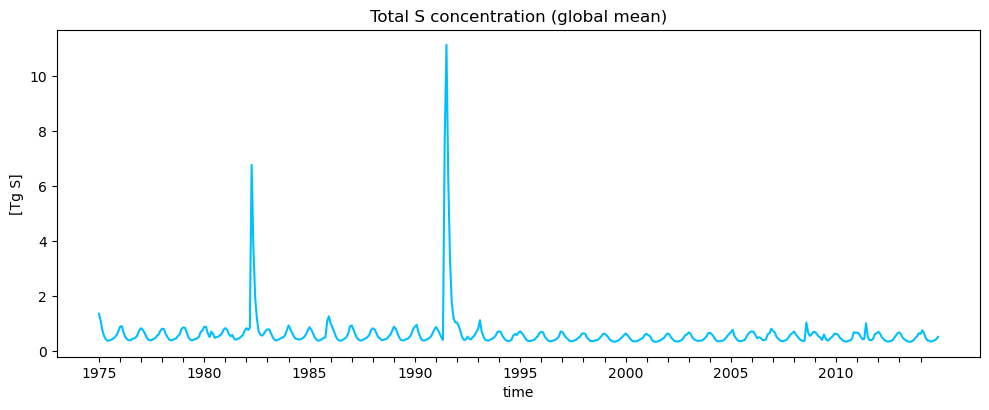

In [19]:
lat = ds_19["lat"]
weighted_lat = np.cos(np.deg2rad(lat))
so2 = ds_19["SO2"].weighted(weighted_lat).mean(dim=["lat", "lon", "lev"])
so2_tg = so2 * K

plt.figure(figsize=(10, 4))
so2_tg.plot(color = "deepskyblue", label = "NorESM2.3")
plt.ylabel("[Tg S]")
years = np.arange(1975, 2015)  
year_ticks = [cftime.DatetimeNoLeap(int(y), 1, 1) for y in years]
plt.xticks(
    year_ticks,
    [str(y) if y % 5 == 0 else '' for y in years]
)
plt.tight_layout()
plt.title("Total S concentration (global mean)")

In [20]:
so2_profile_19 = ds_19["SO2"].weighted(weighted_lat)
so2_time_lev_19 = so2_profile_19.mean(dim=['lat','lon'])
so2_zoom_19= so2_time_lev_19.sel(time=slice('1991-01-01', '1992-12-01'))
time_zoom_19 = so2_zoom_19['time'].values
lev_19 = ds_19['lev'].values

In [21]:
so2_profile_22 = ds_22["SO2"].weighted(weighted_lat_22)
so2_time_lev_22 = so2_profile_22.mean(dim=['lat','lon'])
so2_zoom_22 = so2_time_lev_22.sel(time=slice('1991-01-01', '1992-12-01'))
time_zoom_22 = so2_zoom_22['time'].values
lev_22 = ds_22['lev'].values

In [22]:
so2_profile_19_c = ds_19_c["SO2"].weighted(weighted_lat_19_c)
so2_time_lev_19_c = so2_profile_19_c.mean(dim=['lat','lon'])
so2_zoom_19_c = so2_time_lev_19_c.sel(time=slice('1991-01-01', '1992-12-01'))
time_zoom_19_c = so2_zoom_19_c['time'].values 
lev_19_c = ds_19_c['lev'].values

In [23]:
so2_profile_24 = ds_24["SO2"].weighted(weighted_lat_24)
so2_time_lev_24 = so2_profile_24.mean(dim=['lat','lon'])
so2_zoom_24 = so2_time_lev_24.sel(time=slice('1991-01-01', '1992-12-01'))
time_zoom_24 = so2_zoom_24['time'].values 
lev_24 = ds_24['lev'].values


In [24]:
so2_profile_1825 = ds_1825["SO2"].weighted(weighted_lat_1825)
so2_time_lev_1825 = so2_profile_1825.mean(dim=['lat','lon'])
so2_zoom_1825 = so2_time_lev_1825.sel(time=slice('1991-01-01', '1992-12-01'))
time_zoom_1825 = so2_zoom_1825['time'].values
lev_1825 = ds_1825['lev'].values

In [25]:
so2_profile_1825_17tg = ds_1825_17tg["SO2"].weighted(weighted_lat_1825_17tg)
so2_time_lev_1825_17tg = so2_profile_1825_17tg.mean(dim=['lat','lon'])
so2_zoom_1825_17tg = so2_time_lev_1825_17tg.sel(time=slice('1991-01-01', '1992-12-01'))
time_zoom_1825_17tg = so2_zoom_1825_17tg['time'].values
lev_1825_17tg = ds_1825_17tg['lev'].values

In [26]:
so2_profile_1tg = ds_1tg["SO2"].weighted(weighted_lat_1tg)
so2_time_lev_1tg = so2_profile_1tg.mean(dim=['lat','lon'])
so2_zoom_1tg = so2_time_lev_1tg.sel(time=slice('1991-01-01', '1992-12-01'))
time_zoom_1tg = so2_zoom_1tg['time'].values
lev_1tg = ds_1tg['lev'].values

In [27]:
so2_profile_1pr = ds_1pr["SO2"].weighted(weighted_lat_1pr)
so2_time_lev_1pr = so2_profile_1pr.mean(dim=['lat','lon'])
so2_zoom_1pr = so2_time_lev_1pr.sel(time=slice('1991-01-01', '1992-12-01'))
time_zoom_1pr = so2_zoom_1pr['time'].values
lev_1pr = ds_1pr['lev'].values

In [28]:
so2_profile_60tg = ds_60tg["SO2"].weighted(weighted_lat_60tg)
so2_time_lev_60tg = so2_profile_60tg.mean(dim=['lat','lon'])
so2_zoom_60tg = so2_time_lev_60tg.sel(time=slice('1991-01-01', '1992-12-01'))
time_zoom_60tg = so2_zoom_60tg['time'].values
lev_60tg = ds_60tg['lev'].values

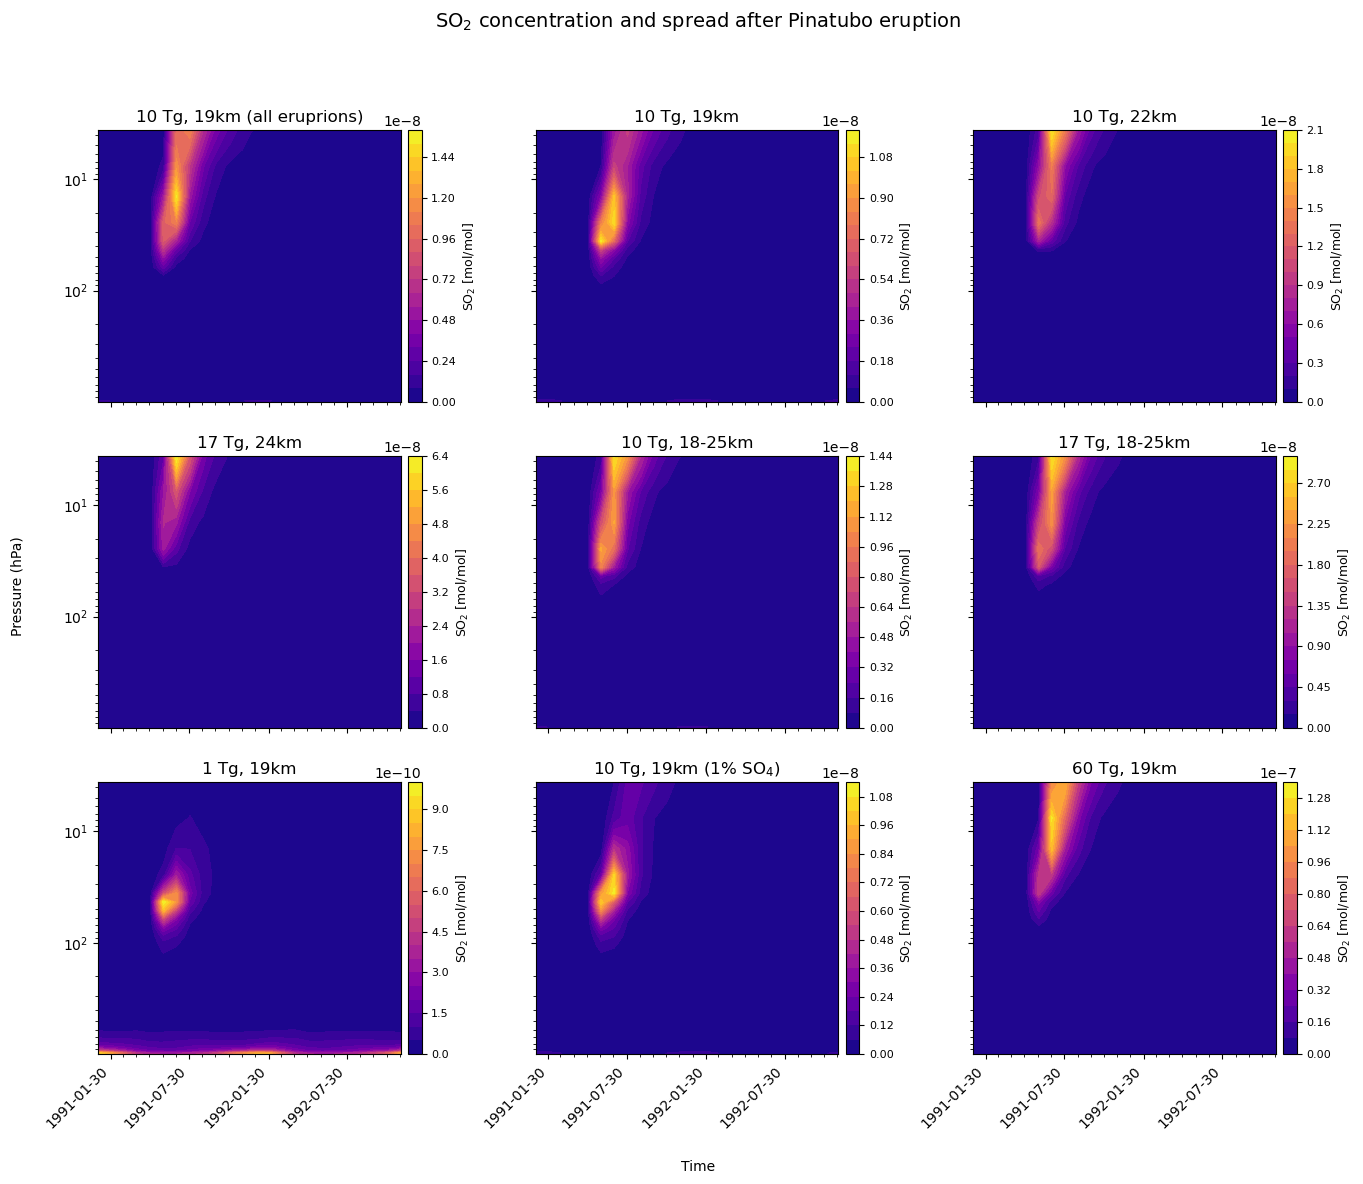

In [29]:
all_so2 = [so2_zoom_19, so2_zoom_19_c, so2_zoom_22, so2_zoom_24, so2_zoom_1825, 
           so2_zoom_1825_17tg, so2_zoom_1tg, so2_zoom_1pr, so2_zoom_60tg]

all_times = [time_zoom_19, time_zoom_19_c, time_zoom_22, time_zoom_24, time_zoom_1825, 
             time_zoom_1825_17tg, time_zoom_1tg, time_zoom_1pr, time_zoom_60tg]

all_lev = [lev_19, lev_19_c, lev_22, lev_24, lev_1825, 
             lev_1825_17tg, lev_1tg, lev_1pr, lev_60tg]

titles = ["10 Tg, 19km (all eruprions)", "10 Tg, 19km", "10 Tg, 22km", "17 Tg, 24km", 
          "10 Tg, 18-25km", "17 Tg, 18-25km", "1 Tg, 19km", 
          "10 Tg, 19km (1% SO$_4$)", "60 Tg, 19km"]

fig, axs = plt.subplots(3, 3, figsize=(16, 12), sharex=True, sharey=True)

for i, ax in enumerate(axs.flat):
    if i < len(all_so2):
        cf = ax.contourf(all_times[i], all_lev[i], all_so2[i].T, 
                         levels=20, cmap='plasma')
        
        ax.set_yscale("log")
        ax.invert_yaxis()
        
        cbar = fig.colorbar(cf, ax=ax, pad=0.02)
        cbar.ax.tick_params(labelsize=8) 
        cbar.set_label("SO$_2$ [mol/mol]", fontsize=9)
        
        ax.set_title(titles[i], fontsize=12)
        ax.xaxis.set_minor_locator(mdates.MonthLocator(interval=1))
        ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))

for ax in axs[2, :]:
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

fig.supxlabel('Time', fontsize=10)
fig.supylabel('Pressure (hPa)', fontsize=10, x=0.07)
fig.suptitle("SO$_2$ concentration and spread after Pinatubo eruption", fontsize=14)

plt.tight_layout
plt.show()

### H2SO4 and sulfate

Text(0.5, 1.0, 'Total H2SO4 concentration (global mean)')

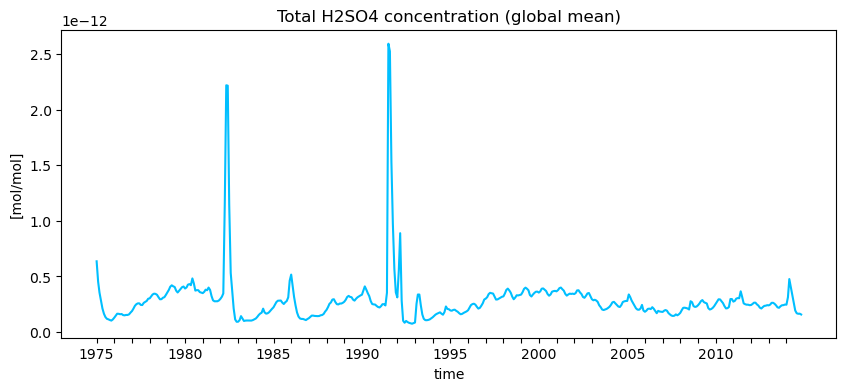

In [30]:
so4 = ds_19["H2SO4"].weighted(weighted_lat).mean(dim=["lat", "lon", "lev"])


plt.figure(figsize=(10, 4))
so4.plot(color = "deepskyblue", label = "NorESM2.3")
plt.ylabel("[mol/mol]")
years = np.arange(1975, 2015)  
year_ticks = [cftime.DatetimeNoLeap(int(y), 1, 1) for y in years]
plt.xticks(
    year_ticks,
    [str(y) if y % 5 == 0 else '' for y in years]
)
plt.title("Total H2SO4 concentration (global mean)")

Text(0.5, 1.0, 'Mass mixing ratio of Sulfate (global mean)')

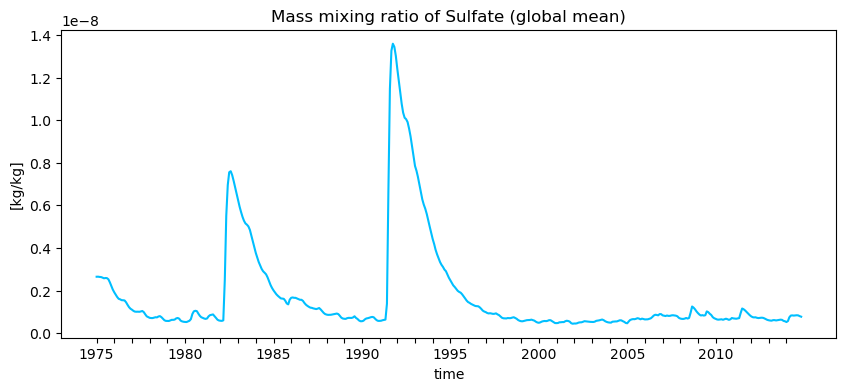

In [31]:
mmr_so4 = ds_19["mmr_SULFATE"].weighted(weighted_lat).mean(dim=["lat", "lon", "lev"])


plt.figure(figsize=(10, 4))
mmr_so4.plot(color = "deepskyblue", label = "NorESM2.3")
plt.ylabel("[kg/kg]")
years = np.arange(1975, 2015)  
year_ticks = [cftime.DatetimeNoLeap(int(y), 1, 1) for y in years]
plt.xticks(
    year_ticks,
    [str(y) if y % 5 == 0 else '' for y in years]
)
plt.title("Mass mixing ratio of Sulfate (global mean)")

In [32]:
tropopause = ds_19["TROP_P"].weighted(weighted_lat).mean(dim=["lat", "lon"])
tropopause_22 = ds_22["TROP_P"].weighted(weighted_lat_22).mean(dim=["lat", "lon"])
tropopause_19_c = ds_19_c["TROP_P"].weighted(weighted_lat_19_c).mean(dim=["lat", "lon"])
tropopause_24 = ds_24["TROP_P"].weighted(weighted_lat_24).mean(dim=["lat", "lon"])
tropopause_1825 = ds_1825["TROP_P"].weighted(weighted_lat_1825).mean(dim=["lat", "lon"])
tropopause_1825_17tg = ds_1825_17tg["TROP_P"].weighted(weighted_lat_1825_17tg).mean(dim=["lat", "lon"])
tropopause_1tg = ds_1tg["TROP_P"].weighted(weighted_lat_1tg).mean(dim=["lat", "lon"])
tropopause_1pr= ds_1pr["TROP_P"].weighted(weighted_lat_1pr).mean(dim=["lat", "lon"])
tropopause_60tg= ds_60tg["TROP_P"].weighted(weighted_lat_60tg).mean(dim=["lat", "lon"])

Text(0.5, 1.0, 'Stratospheric burden of Sulfate (global mean)')

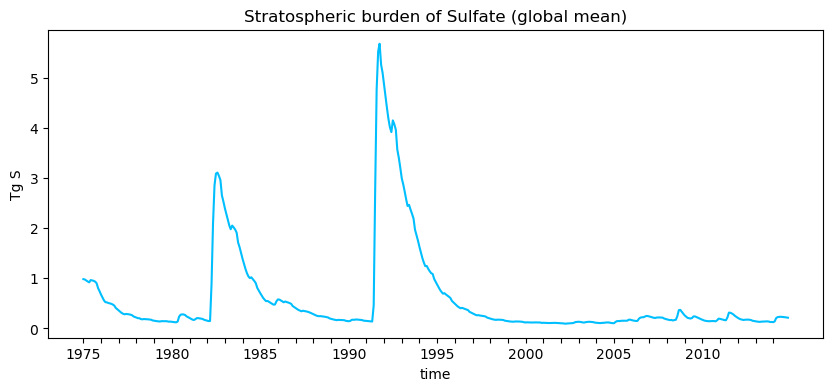

In [33]:
p_lev = tropopause * 0.01
p_lev_22 = tropopause_22 * 0.01
p_lev_19_c = tropopause_19_c * 0.01
p_lev_24 = tropopause_24 * 0.01
p_lev_1825 = tropopause_1825 * 0.01
p_lev_1825_17tg = tropopause_1825_17tg * 0.01
p_lev_1tg = tropopause_1tg * 0.01
p_lev_1pr = tropopause_1pr * 0.01
p_lev_60tg = tropopause_60tg * 0.01
M_strat_air = 0.099 * Matmos   #9.9% of the total mass of the atmosphere
Mo = 15.999
Mso4 = Ms + (4 * Mo)
c = Ms/Mso4

mmr_sulf = ds_19["mmr_SULFATE"]
so4_burd = mmr_sulf.where(mmr_sulf["lev"] <= p_lev)
so4_burd = so4_burd.weighted(weighted_lat).mean(dim=["lat", "lon", "lev"])
#so4_burd = so4_burd.weighted(weighted_lev_19).mean(dim="lev")
so4_burden = so4_burd * M_strat_air *10**(-12)
so4_burden_TgS = so4_burden * c

mmr_sulf_22 = ds_22["mmr_SULFATE"]
so4_burd_22 = mmr_sulf_22.where(mmr_sulf_22["lev"] <= p_lev_22)
so4_burd_22 = so4_burd_22.weighted(weighted_lat_22).mean(dim=["lat", "lon", "lev"])
#so4_burd_22 = so4_burd_22.weighted(weighted_lev_22).mean(dim="lev")
so4_burden_22 = so4_burd_22 * M_strat_air *10**(-12)
so4_burden_TgS_22 = so4_burden_22 * c

mmr_sulf_19_c = ds_19_c["mmr_SULFATE"]
so4_burd_19_c = mmr_sulf_19_c.where(mmr_sulf_19_c["lev"] <= p_lev_19_c)
so4_burd_19_c = so4_burd_19_c.weighted(weighted_lat_19_c).mean(dim=["lat", "lon", "lev"])
#so4_burd_19_c = so4_burd_19_c.weighted(weighted_lev_19_c).mean(dim="lev")
so4_burden_19_c = so4_burd_19_c * M_strat_air *10**(-12)
so4_burden_TgS_19_c = so4_burden_19_c * c

mmr_sulf_24 = ds_24["mmr_SULFATE"]
so4_burd_24 = mmr_sulf_24.where(mmr_sulf_24["lev"] <= p_lev_24)
so4_burd_24 = so4_burd_24.weighted(weighted_lat_24).mean(dim=["lat", "lon", "lev"])
#so4_burd_24 = so4_burd_24.weighted(weighted_lev_24).mean(dim="lev")
so4_burden_24 = so4_burd_24 * M_strat_air *10**(-12)
so4_burden_TgS_24 = so4_burden_24 * c

mmr_sulf_1825 = ds_1825["mmr_SULFATE"]
so4_burd_1825 = mmr_sulf_1825.where(mmr_sulf_1825["lev"] <= p_lev_1825)
so4_burd_1825 = so4_burd_1825.weighted(weighted_lat_1825).mean(dim=["lat", "lon", "lev"])
#so4_burd_1825 = so4_burd_1825.weighted(weighted_lev_1825).mean(dim="lev")
so4_burden_1825 = so4_burd_1825 * M_strat_air *10**(-12)
so4_burden_TgS_1825 = so4_burden_1825 * c

mmr_sulf_1825_17tg = ds_1825_17tg["mmr_SULFATE"]
so4_burd_1825_17tg = mmr_sulf_1825_17tg.where(mmr_sulf_1825_17tg["lev"] <= p_lev_1825_17tg)
so4_burd_1825_17tg = so4_burd_1825_17tg.weighted(weighted_lat_1825_17tg).mean(dim=["lat", "lon", "lev"])
#so4_burd_1825_17tg = so4_burd_1825_17tg.weighted(weighted_lev_1825_17tg).mean(dim="lev")
so4_burden_1825_17tg = so4_burd_1825_17tg * M_strat_air *10**(-12)
so4_burden_TgS_1825_17tg = so4_burden_1825_17tg * c

mmr_sulf_1tg = ds_1tg["mmr_SULFATE"]
so4_burd_1tg = mmr_sulf_1tg.where(mmr_sulf_1tg["lev"] <= p_lev_1tg)
so4_burd_1tg = so4_burd_1tg.weighted(weighted_lat_1tg).mean(dim=["lat", "lon", "lev"])
#so4_burd_1tg = so4_burd_1tg.weighted(weighted_lev_1tg).mean(dim="lev")
so4_burden_1tg = so4_burd_1tg * M_strat_air *10**(-12)
so4_burden_TgS_1tg = so4_burden_1tg * c

mmr_sulf_1pr = ds_1pr["mmr_SULFATE"]
so4_burd_1pr = mmr_sulf_1pr.where(mmr_sulf_1pr["lev"] <= p_lev_1pr)
so4_burd_1pr = so4_burd_1pr.weighted(weighted_lat_1pr).mean(dim=["lat", "lon", "lev"])
#so4_burd_1pr = so4_burd_1pr.weighted(weighted_lev_1pr).mean(dim="lev")
so4_burden_1pr = so4_burd_1pr * M_strat_air *10**(-12)
so4_burden_TgS_1pr = so4_burden_1pr * c

mmr_sulf_60tg = ds_60tg["mmr_SULFATE"]
so4_burd_60tg = mmr_sulf_60tg.where(mmr_sulf_60tg["lev"] <= p_lev_60tg)
so4_burd_60tg = so4_burd_60tg.weighted(weighted_lat_60tg).mean(dim=["lat", "lon", "lev"])
#so4_burd_60tg = so4_burd_60tg.weighted(weighted_lev_60tg).mean(dim="lev")
so4_burden_60tg = so4_burd_60tg * M_strat_air *10**(-12)
so4_burden_TgS_60tg = so4_burden_60tg * c

plt.figure(figsize=(10, 4))
so4_burden_TgS.plot(color = "deepskyblue", label = "NorESM2.3")
plt.ylabel("Tg S")
years = np.arange(1975, 2015)  
year_ticks = [cftime.DatetimeNoLeap(int(y), 1, 1) for y in years]
plt.xticks(
    year_ticks,
    [str(y) if y % 5 == 0 else '' for y in years]
)
plt.title("Stratospheric burden of Sulfate (global mean)")

Text(0.5, 1.0, 'Stratospheric burden of Sulfate from Pinatubo (global mean)')

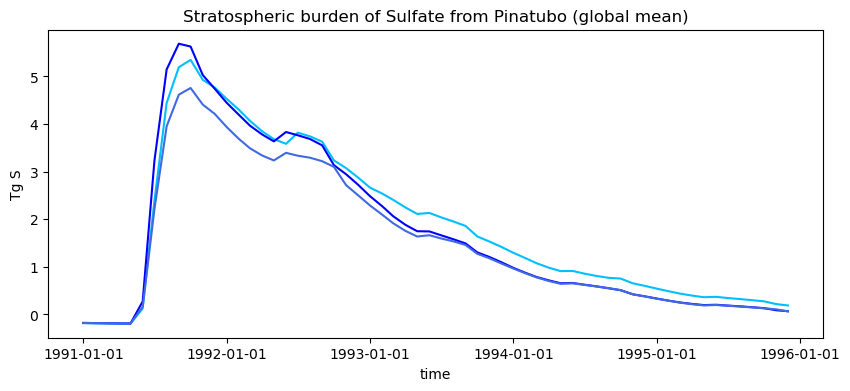

In [34]:
background = so4_burden_TgS.sel(time=[t for t in so4_burden_TgS.time.values if 1985 <= t.year <= 1990]).mean(dim="time")
so4_burd_Pinatubo = so4_burden_TgS.sel(time=[t for t in so4_burden_TgS.time.values if 1991 <= t.year <= 1995])
so4_burden_Pinatubo = so4_burd_Pinatubo - background
so4_burden_Pinatubo_22 = so4_burden_TgS_22 - background
so4_burden_Pinatubo_19_c = so4_burden_TgS_19_c- background
so4_burden_Pinatubo_24 = so4_burden_TgS_24- background
so4_burden_Pinatubo_1825 = so4_burden_TgS_1825- background
so4_burden_Pinatubo_1825_17tg = so4_burden_TgS_1825_17tg- background
so4_burden_Pinatubo_1tg = so4_burden_TgS_1tg- background
so4_burden_Pinatubo_1pr = so4_burden_TgS_1pr- background
so4_burden_Pinatubo_60tg = so4_burden_TgS_60tg- background

plt.figure(figsize=(10, 4))
so4_burden_Pinatubo.plot(color = "deepskyblue", label = "NorESM2.3, all eruptions in: 10Tg, 19km")
so4_burden_Pinatubo_22.plot(color = "blue", label = "NorESM2.3: 10Tg, 22km")
so4_burden_Pinatubo_19_c.plot(color = "royalblue", label = "NorESM2.3: 10Tg, 19km")
years = np.arange(1991, 1997) 
year_ticks = [cftime.DatetimeNoLeap(y, 1, 1) for y in years]
plt.xticks(
    year_ticks
)
plt.ylabel("Tg S")
plt.title("Stratospheric burden of Sulfate from Pinatubo (global mean)")

In [35]:
a_glob = 510000000
h_trop = 4440
d = 12756

a_trop = np.pi * d * h_trop
ratio = a_trop/a_glob

Text(0.5, 1.0, 'Stratospheric burden of Sulfate (Tropics)')

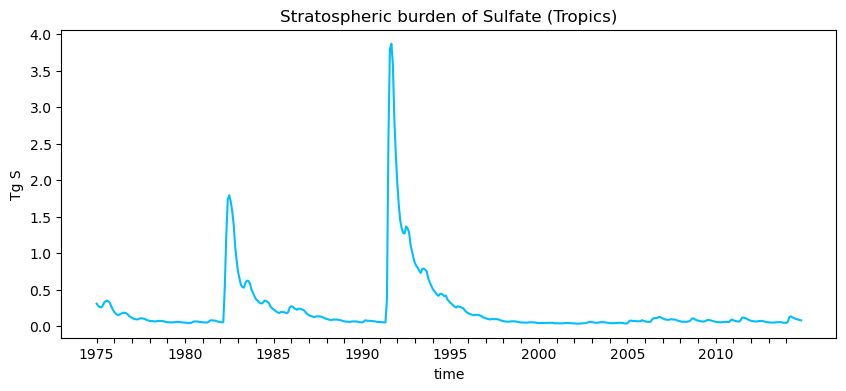

In [36]:
so4_trop = mmr_sulf.sel(lat=slice(-20, 20))
so4_burd_trop = so4_trop.where(so4_trop["lev"] <= p_lev)
so4_burd_trop = so4_burd_trop.weighted(weighted_lat).mean(dim=["lat", "lon", "lev"])
#so4_burd_trop = so4_burd_trop.weighted(weighted_lev_19).mean(dim="lev")
so4_burden_trop = so4_burd_trop * M_strat_air * ratio *10**(-12)
so4_burden_TgS_trop = so4_burden_trop * c
background_trop = so4_burden_TgS_trop.sel(time=[t for t in so4_burden_TgS_trop.time.values if 1985 <= t.year <= 1990]).mean(dim="time")
so4_burden_TgS_trop_Pin = so4_burden_TgS_trop.sel(time=[t for t in so4_burden_TgS_trop.time.values if 1991 <= t.year <= 1995]) - background_trop

so4_trop_22 = mmr_sulf_22.sel(lat=slice(-20, 20))
so4_burd_trop_22 = so4_trop_22.where(so4_trop_22["lev"] <= p_lev_22)
so4_burd_trop_22 = so4_burd_trop_22.weighted(weighted_lat_22).mean(dim=["lat", "lon", "lev"])
#so4_burd_trop_22 = so4_burd_trop_22.weighted(weighted_lev_22).mean(dim="lev")
so4_burden_trop_22 = so4_burd_trop_22 * M_strat_air * ratio *10**(-12)
so4_burden_TgS_trop_22 = so4_burden_trop_22 * c
so4_burden_TgS_trop_22 = so4_burden_TgS_trop_22 - background_trop

so4_trop_19_c = mmr_sulf_19_c.sel(lat=slice(-20, 20))
so4_burd_trop_19_c = so4_trop_19_c.where(so4_trop_19_c["lev"] <= p_lev_19_c)
so4_burd_trop_19_c = so4_burd_trop_19_c.weighted(weighted_lat_19_c).mean(dim=["lat", "lon", "lev"])
#so4_burd_trop_19_c = so4_burd_trop_19_c.weighted(weighted_lev_19_c).mean(dim="lev")
so4_burden_trop_19_c = so4_burd_trop_19_c * M_strat_air * ratio *10**(-12)
so4_burden_TgS_trop_19_c = so4_burden_trop_19_c * c
so4_burden_TgS_trop_19_c =so4_burden_TgS_trop_19_c - background_trop

so4_trop_24= mmr_sulf_24.sel(lat=slice(-20, 20))
so4_burd_trop_24 = so4_trop_24.where(so4_trop_24["lev"] <= p_lev_24)
so4_burd_trop_24 = so4_burd_trop_24.weighted(weighted_lat_24).mean(dim=["lat", "lon", "lev"])
#so4_burd_trop_24 = so4_burd_trop_24.weighted(weighted_lev_24).mean(dim="lev")
so4_burden_trop_24 = so4_burd_trop_24 * M_strat_air * ratio *10**(-12)
so4_burden_TgS_trop_24 = so4_burden_trop_24 * c
so4_burden_TgS_trop_24 = so4_burden_TgS_trop_24 - background_trop

so4_trop_1825= mmr_sulf_1825.sel(lat=slice(-20, 20))
so4_burd_trop_1825 = so4_trop_1825.where(so4_trop_1825["lev"] <= p_lev_1825)
so4_burd_trop_1825 = so4_burd_trop_1825.weighted(weighted_lat_1825).mean(dim=["lat", "lon", "lev"])
#so4_burd_trop_1825 = so4_burd_trop_1825.weighted(weighted_lev_19).mean(dim="lev")
so4_burden_trop_1825 = so4_burd_trop_1825 * M_strat_air * ratio *10**(-12)
so4_burden_TgS_trop_1825 = so4_burden_trop_1825 * c
so4_burden_TgS_trop_1825 =so4_burden_TgS_trop_1825 -background_trop

so4_trop_1825_17tg= mmr_sulf_1825_17tg.sel(lat=slice(-20, 20))
so4_burd_trop_1825_17tg = so4_trop_1825_17tg.where(so4_trop_1825_17tg["lev"] <= p_lev_1825_17tg)
so4_burd_trop_1825_17tg = so4_burd_trop_1825_17tg.weighted(weighted_lat_1825_17tg).mean(dim=["lat", "lon", "lev"])
#so4_burd_trop_1825 = so4_burd_trop_1825.weighted(weighted_lev_19).mean(dim="lev")
so4_burden_trop_1825_17tg = so4_burd_trop_1825_17tg * M_strat_air * ratio *10**(-12)
so4_burden_TgS_trop_1825_17tg = so4_burden_trop_1825_17tg * c
so4_burden_TgS_trop_1825_17tg = so4_burden_TgS_trop_1825_17tg -background_trop

so4_trop_1tg= mmr_sulf_1tg.sel(lat=slice(-20, 20))
so4_burd_trop_1tg = so4_trop_1tg.where(so4_trop_1tg["lev"] <= p_lev_1tg)
so4_burd_trop_1tg = so4_burd_trop_1tg.weighted(weighted_lat_1tg).mean(dim=["lat", "lon", "lev"])
#so4_burd_trop_1825 = so4_burd_trop_1825.weighted(weighted_lev_19).mean(dim="lev")
so4_burden_trop_1tg = so4_burd_trop_1tg * M_strat_air * ratio *10**(-12)
so4_burden_TgS_trop_1tg = so4_burden_trop_1tg * c
so4_burden_TgS_trop_1tg = so4_burden_TgS_trop_1tg - background_trop

so4_trop_1pr= mmr_sulf_1pr.sel(lat=slice(-20, 20))
so4_burd_trop_1pr = so4_trop_1pr.where(so4_trop_1pr["lev"] <= p_lev_1pr)
so4_burd_trop_1pr = so4_burd_trop_1pr.weighted(weighted_lat_1pr).mean(dim=["lat", "lon", "lev"])
#so4_burd_trop_1825 = so4_burd_trop_1825.weighted(weighted_lev_19).mean(dim="lev")
so4_burden_trop_1pr = so4_burd_trop_1pr * M_strat_air * ratio *10**(-12)
so4_burden_TgS_trop_1pr = so4_burden_trop_1pr * c
so4_burden_TgS_trop_1pr = so4_burden_TgS_trop_1pr - background_trop

so4_trop_60tg= mmr_sulf_60tg.sel(lat=slice(-20, 20))
so4_burd_trop_60tg = so4_trop_60tg.where(so4_trop_60tg["lev"] <= p_lev_60tg)
so4_burd_trop_60tg = so4_burd_trop_60tg.weighted(weighted_lat_60tg).mean(dim=["lat", "lon", "lev"])
#so4_burd_trop_60tg = so4_burd_trop_60tg.weighted(weighted_lev_60tg).mean(dim="lev")
so4_burden_trop_60tg = so4_burd_trop_60tg * M_strat_air * ratio *10**(-12)
so4_burden_TgS_trop_60tg = so4_burden_trop_60tg * c
so4_burden_TgS_trop_60tg = so4_burden_TgS_trop_60tg - background_trop


plt.figure(figsize=(10, 4))
so4_burden_TgS_trop.plot(color = "deepskyblue", label = "NorESM2.3")
plt.ylabel("Tg S")
years = np.arange(1975, 2015)  
year_ticks = [cftime.DatetimeNoLeap(int(y), 1, 1) for y in years]
plt.xticks(
    year_ticks,
    [str(y) if y % 5 == 0 else '' for y in years]
)
plt.title("Stratospheric burden of Sulfate (Tropics)")

In [37]:
path_obs = "/nird/datapeak/NS1004K/elihho/obs_pinatubo/dataset/Observation"

In [38]:
hirs_sulf_burd = pd.read_csv(f"{path_obs}/hirs_sulf_burd.txt", delim_whitespace=True, header=0,  index_col=0)
sage3l_sulf_burd = pd.read_csv(f"{path_obs}/sage3l_sulf_burd.txt", delim_whitespace=True, header=0,  index_col=0)

start = pd.Timestamp("1991-01-01")
months = [int(c) for c in hirs_sulf_burd.columns]
dates = [start + pd.DateOffset(months=m) for m in months]
hirs_sulf_burd.columns = dates

months_sage = [int(c) for c in sage3l_sulf_burd.columns]
dates_sage = [start + pd.DateOffset(months=m) for m in months_sage]
sage3l_sulf_burd.columns = dates_sage

/tmp/ipykernel_1655135/1286819563.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  hirs_sulf_burd = pd.read_csv(f"{path_obs}/hirs_sulf_burd.txt", delim_whitespace=True, header=0,  index_col=0)
/tmp/ipykernel_1655135/1286819563.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  sage3l_sulf_burd = pd.read_csv(f"{path_obs}/sage3l_sulf_burd.txt", delim_whitespace=True, header=0,  index_col=0)


  agg_filter: a filter function, which takes a (m, n, 3) float array and a dpi value, and returns a (m, n, 3) array and two offsets from the bottom left corner of the image
  alpha: float or None
  animated: bool
  antialiased: bool
  backgroundcolor: :mpltype:`color`
  bbox: dict with properties for `.patches.FancyBboxPatch`
  clip_box: `~matplotlib.transforms.BboxBase` or None
  clip_on: bool
  clip_path: Patch or (Path, Transform) or None
  color or c: :mpltype:`color`
  figure: `~matplotlib.figure.Figure` or `~matplotlib.figure.SubFigure`
  fontfamily or family or fontname: {FONTNAME, 'serif', 'sans-serif', 'cursive', 'fantasy', 'monospace'}
  fontproperties or font or font_properties: `.font_manager.FontProperties` or `str` or `pathlib.Path`
  fontsize or size: float or {'xx-small', 'x-small', 'small', 'medium', 'large', 'x-large', 'xx-large'}
  fontstretch or stretch: {a numeric value in range 0-1000, 'ultra-condensed', 'extra-condensed', 'condensed', 'semi-condensed', 'normal', 

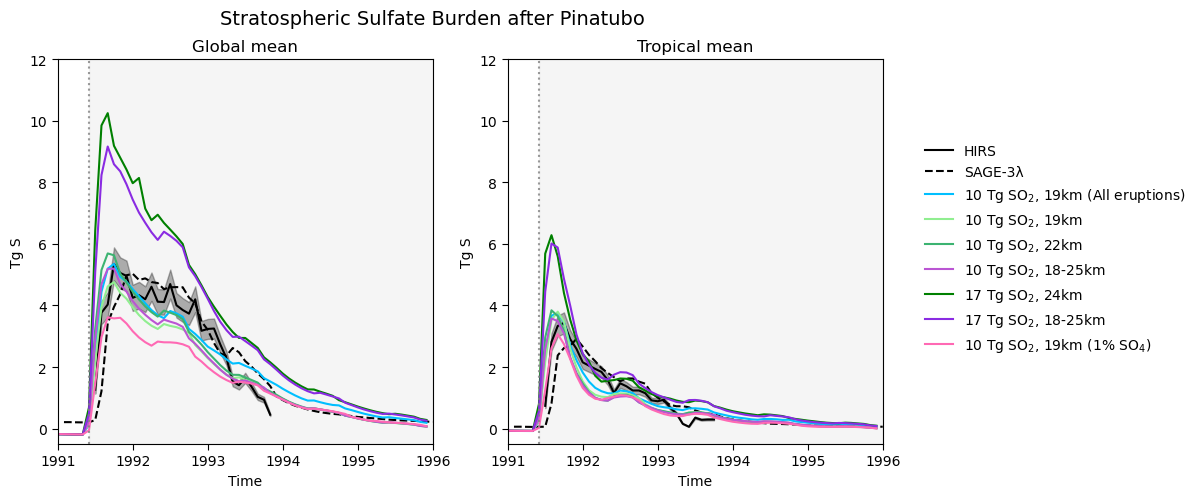

In [89]:
total = hirs_sulf_burd.loc["Total_burden"].astype(float)
trop  = hirs_sulf_burd.loc["Tropical_burden"].astype(float)
err_total = hirs_sulf_burd.loc["Total_burden_error"].astype(float)
err_trop =  hirs_sulf_burd.loc["Tropical_burden_error"].astype(float)
total_sage = sage3l_sulf_burd.loc["Global"].astype(float)
trop_sage  = sage3l_sulf_burd.loc["Tropical"].astype(float)
eruption_date=cftime.DatetimeNoLeap(1991, 6, 1)

obs_time = np.array([t.year + (t.month-1)/12 for t in total_sage.index])
obs_time_hirs = np.array([t.year + (t.month-1)/12 for t in total.index])
time_years = np.array([t.year + (t.month-1)/12 for t in so4_burden_Pinatubo.time.values])
time_years_22 = np.array([t.year + (t.month-1)/12 for t in so4_burden_Pinatubo_22.time.values])
time_years_19_c = np.array([t.year + (t.month-1)/12 for t in so4_burden_Pinatubo_19_c.time.values])
time_years_24 = np.array([t.year + (t.month-1)/12 for t in so4_burden_Pinatubo_24.time.values])
time_years_1825 = np.array([t.year + (t.month-1)/12 for t in so4_burden_Pinatubo_1825.time.values])
time_years_1825_17tg = np.array([t.year + (t.month-1)/12 for t in so4_burden_Pinatubo_1825_17tg.time.values])
time_years_1tg = np.array([t.year + (t.month-1)/12 for t in so4_burden_Pinatubo_1tg.time.values])
time_years_1pr = np.array([t.year + (t.month-1)/12 for t in so4_burden_Pinatubo_1pr.time.values])
time_years_60tg = np.array([t.year + (t.month-1)/12 for t in so4_burden_Pinatubo_60tg.time.values])

obs_time_trop = np.array([t.year + (t.month-1)/12 for t in trop_sage.index])
obs_time_hirs_trop = np.array([t.year + (t.month-1)/12 for t in trop.index])
time_years_trop = np.array([t.year + (t.month-1)/12 for t in so4_burden_TgS_trop_Pin.time.values])
time_years_trop_22 = np.array([t.year + (t.month-1)/12 for t in so4_burden_TgS_trop_22.time.values])
time_years_trop_19_c = np.array([t.year + (t.month-1)/12 for t in so4_burden_TgS_trop_19_c.time.values])
time_years_trop_24 = np.array([t.year + (t.month-1)/12 for t in so4_burden_TgS_trop_24.time.values])
time_years_trop_1825 = np.array([t.year + (t.month-1)/12 for t in so4_burden_TgS_trop_1825.time.values])
time_years_trop_1825_17tg = np.array([t.year + (t.month-1)/12 for t in so4_burden_TgS_trop_1825_17tg.time.values])
time_years_trop_1tg = np.array([t.year + (t.month-1)/12 for t in so4_burden_TgS_trop_1tg.time.values])
time_years_trop_1pr = np.array([t.year + (t.month-1)/12 for t in so4_burden_TgS_trop_1pr.time.values])
time_years_trop_60tg = np.array([t.year + (t.month-1)/12 for t in so4_burden_TgS_trop_60tg.time.values])


fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].plot(obs_time_hirs, total, color="black", label="HIRS")
ax[0].fill_between(obs_time_hirs, total - err_total, total + err_total,
                 color="black", alpha=0.3)
ax[0].plot(obs_time, total_sage, color="black", linestyle="--", label="SAGE-3λ")
ax[0].plot(time_years, so4_burden_Pinatubo, color = "deepskyblue", label = "10 Tg SO$_2$, 19km (All eruptions)")
ax[0].plot(time_years_19_c, so4_burden_Pinatubo_19_c, color = "lightgreen", label = "10 Tg SO$_2$, 19km")
ax[0].plot(time_years_22, so4_burden_Pinatubo_22, color = "mediumseagreen", label = "10 Tg SO$_2$, 22km")
ax[0].plot(time_years_1825, so4_burden_Pinatubo_1825, color = "mediumorchid", label = "10 Tg SO$_2$, 18-25km")
ax[0].plot(time_years_24, so4_burden_Pinatubo_24, color = "green", label = "17 Tg SO$_2$, 24km")
ax[0].plot(time_years_1825_17tg, so4_burden_Pinatubo_1825_17tg, color = "blueviolet", label = "17 Tg SO$_2$, 18-25km")
#ax[0].plot(time_years_1tg, so4_burden_Pinatubo_1tg, color="orange", label="1 Tg SO2, 19km")
ax[0].plot(time_years_1pr, so4_burden_Pinatubo_1pr, color="hotpink", label="10 Tg SO$_2$, 19km (1% SO$_4$)")
#ax[0].plot(time_years_60tg, so4_burden_Pinatubo_60tg, color="cornflowerblue", label="60 Tg SO2, 19km")
ax[0].set_xlabel("Time")
ax[0].set_ylabel("Tg S")
ax[0].set_ylim(-0.5,12)
ax[0].set_title("Global mean", fontsize=12)

ax[1].plot(obs_time_hirs_trop,  trop,  color="black", label="HIRS")
ax[1].fill_between(obs_time_hirs_trop, trop - err_trop, trop + err_trop,
                 color="black", alpha=0.3)
ax[1].plot(obs_time_trop, trop_sage, color="black", linestyle="--", label="SAGE-3λ")
ax[1].plot(time_years_trop, so4_burden_TgS_trop_Pin, color = "deepskyblue", label = "10 Tg SO$_2$, 19km (All eruptions)" )
ax[1].plot(time_years_trop_19_c, so4_burden_TgS_trop_19_c, color = "lightgreen", label = "10 Tg SO$_2$, 19km")
ax[1].plot(time_years_trop_22, so4_burden_TgS_trop_22, color = "mediumseagreen", label = "10 Tg SO$_2$, 22km")
ax[1].plot(time_years_trop_1825, so4_burden_TgS_trop_1825, color = "mediumorchid", label = "10 Tg SO$_2$, 18-25km")
ax[1].plot(time_years_trop_24, so4_burden_TgS_trop_24, color = "green", label = "17 Tg SO$_2$, 24km")
ax[1].plot(time_years_trop_1825_17tg, so4_burden_TgS_trop_1825_17tg, color = "blueviolet", label = "17 Tg SO$_2$, 18-25km")
#ax[1].plot(time_years_trop_1tg, so4_burden_TgS_trop_1tg, color="orange", label="1 Tg SO2, 19km")
ax[1].plot(time_years_trop_1pr, so4_burden_TgS_trop_1pr, color="hotpink", label="10 Tg SO$_2$, 19km (1% SO$_4$)")
#ax[1].plot(time_years_trop_60tg, so4_burden_trop_60tg, color="cornflowerblue", label="60 Tg SO2, 19km")
ax[1].set_xlabel("Time")
ax[1].set_ylabel("Tg S")
ax[1].set_ylim(-0.5,12)
ax[1].set_title("Tropical mean", fontsize=12)

eruption_float = 1991 + (6-1)/12  
end_float = 1996 + (1-1)/12     

for i, a in enumerate(ax):
    a.axvline(eruption_float, color='gray', ls=":", alpha=0.8)
    a.axvspan(eruption_float, end_float, color='gray', alpha=0.08, zorder=0)
    
    a.tick_params(direction='out', length=4)

    a.set_xticks([1991, 1992, 1993, 1994, 1995, 1996])
    a.set_xticklabels(["1991", "1992", "1993", "1994", "1995", "1996"])
    
    plt.setp(a.get_xticklabels())
    
    a.set_xlim(1991, 1996)

handles, labels = ax[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="center left",
    bbox_to_anchor=(0.98, 0.5),
    frameon=False
)

fig.suptitle("Stratospheric Sulfate Burden after Pinatubo", fontsize=14)
fig.subplots_adjust(right=0.95)
plt.show()


  agg_filter: a filter function, which takes a (m, n, 3) float array and a dpi value, and returns a (m, n, 3) array and two offsets from the bottom left corner of the image
  alpha: float or None
  animated: bool
  antialiased: bool
  backgroundcolor: :mpltype:`color`
  bbox: dict with properties for `.patches.FancyBboxPatch`
  clip_box: `~matplotlib.transforms.BboxBase` or None
  clip_on: bool
  clip_path: Patch or (Path, Transform) or None
  color or c: :mpltype:`color`
  figure: `~matplotlib.figure.Figure` or `~matplotlib.figure.SubFigure`
  fontfamily or family or fontname: {FONTNAME, 'serif', 'sans-serif', 'cursive', 'fantasy', 'monospace'}
  fontproperties or font or font_properties: `.font_manager.FontProperties` or `str` or `pathlib.Path`
  fontsize or size: float or {'xx-small', 'x-small', 'small', 'medium', 'large', 'x-large', 'xx-large'}
  fontstretch or stretch: {a numeric value in range 0-1000, 'ultra-condensed', 'extra-condensed', 'condensed', 'semi-condensed', 'normal', 

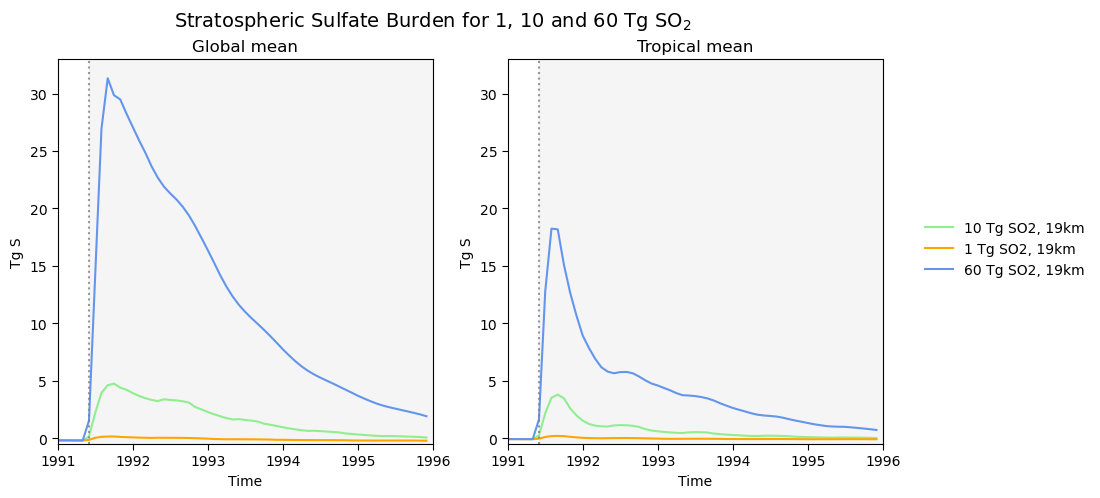

In [90]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].plot(time_years_19_c, so4_burden_Pinatubo_19_c, color = "lightgreen", label = "10 Tg SO2, 19km")
ax[0].plot(time_years_1tg, so4_burden_Pinatubo_1tg, color="orange", label="1 Tg SO2, 19km")
ax[0].plot(time_years_60tg, so4_burden_Pinatubo_60tg, color="cornflowerblue", label="60 Tg SO2, 19km")
ax[0].set_xlabel("Time")
ax[0].set_ylabel("Tg S")
ax[0].set_ylim(-0.5,33)
ax[0].set_title("Global mean", fontsize=12)

ax[1].plot(time_years_trop_19_c, so4_burden_TgS_trop_19_c, color = "lightgreen", label = "10 Tg SO2, 19km")
ax[1].plot(time_years_trop_1tg, so4_burden_TgS_trop_1tg, color="orange", label="1 Tg SO2, 19km")
ax[1].plot(time_years_trop_60tg, so4_burden_TgS_trop_60tg, color="cornflowerblue", label="60 Tg SO2, 19km")
ax[1].set_xlabel("Time")
ax[1].set_ylabel("Tg S")
ax[1].set_ylim(-0.5,33)
ax[1].set_title("Tropical mean", fontsize=12)

eruption_float = 1991 + (6-1)/12  
end_float = 1996 + (1-1)/12     

for i, a in enumerate(ax):
    a.axvline(eruption_float, color='gray', ls=":", alpha=0.8)
    a.axvspan(eruption_float, end_float, color='gray', alpha=0.08, zorder=0)
    
    a.tick_params(direction='out', length=4)

    a.set_xticks([1991, 1992, 1993, 1994, 1995, 1996])
    a.set_xticklabels(["1991", "1992", "1993", "1994", "1995", "1996"])
    
    plt.setp(a.get_xticklabels())
    
    a.set_xlim(1991, 1996)
    
handles, labels = ax[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="center left",
    bbox_to_anchor=(0.98, 0.5),
    frameon=False
)

fig.suptitle("Stratospheric Sulfate Burden for 1, 10 and 60 Tg SO$_2$", fontsize=14)
fig.subplots_adjust(right=0.95)
plt.show()


<Figure size 700x500 with 0 Axes>

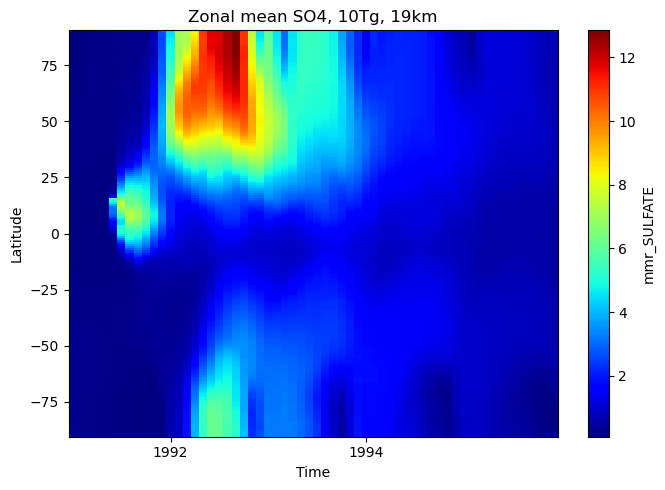

In [46]:
mmr_sulf = ds_19_c["mmr_SULFATE"]
so4_burd = mmr_sulf.sel(lev=50, method="nearest")
so4_burd = so4_burd.mean(dim=["lon"])
so4_burden = so4_burd * M_strat_air *10**(-12)
so4_burden_TgS = so4_burden * c

lat = so4_burden_TgS["lat"].values

plt.figure(figsize=(7,5))
so4_burden_TgS.plot.pcolormesh(
    x="time",
    y="lat",
    cmap="jet",
    figsize=(7,5)
)

plt.xlabel("Time")
plt.ylabel("Latitude")
plt.title("Zonal mean SO4, 10Tg, 19km")
plt.tight_layout()
plt.show()

In [47]:
def plot_so4_lat_time(ds,
    plot_period=("1991-01-01", "1996-01-01"),
    eruption_time=cftime.DatetimeNoLeap(1991, 6, 15),
    lat_marker=15,
    ax=None,
    title=None,
    add_colorbar=True,
):
    mmr_sulf = ds["mmr_SULFATE"]
    so4_burd = mmr_sulf.where(mmr_sulf["lev"] <= p_lev).mean(dim = "lev")
    so4_burd = so4_burd.mean(dim=["lon"])
    so4_burden = so4_burd * M_strat_air *10**(-12)
    so4_burden_TgS = so4_burden * c

    so4_sel = so4_burden_TgS.sel(time=slice(*plot_period))

    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 5))

    p = so4_sel.T.plot(
        ax=ax,
        x="time",
        y="lat",
        cmap="plasma", 
        add_colorbar=add_colorbar,
        cbar_kwargs={"label": "SO4 concentration [ppb]"} if add_colorbar else None
    )

    if eruption_time is not None:
        ax.plot(
            eruption_time,
            lat_marker,
            marker="^",
            color="red",
            markersize=9,
            zorder=5,
        )
    ax.xaxis.set_minor_locator(mdates.YearLocator())
    ax.set_xlabel("")
    ax.set_ylabel("")

    if title:
        ax.set_title(title)

    return ax

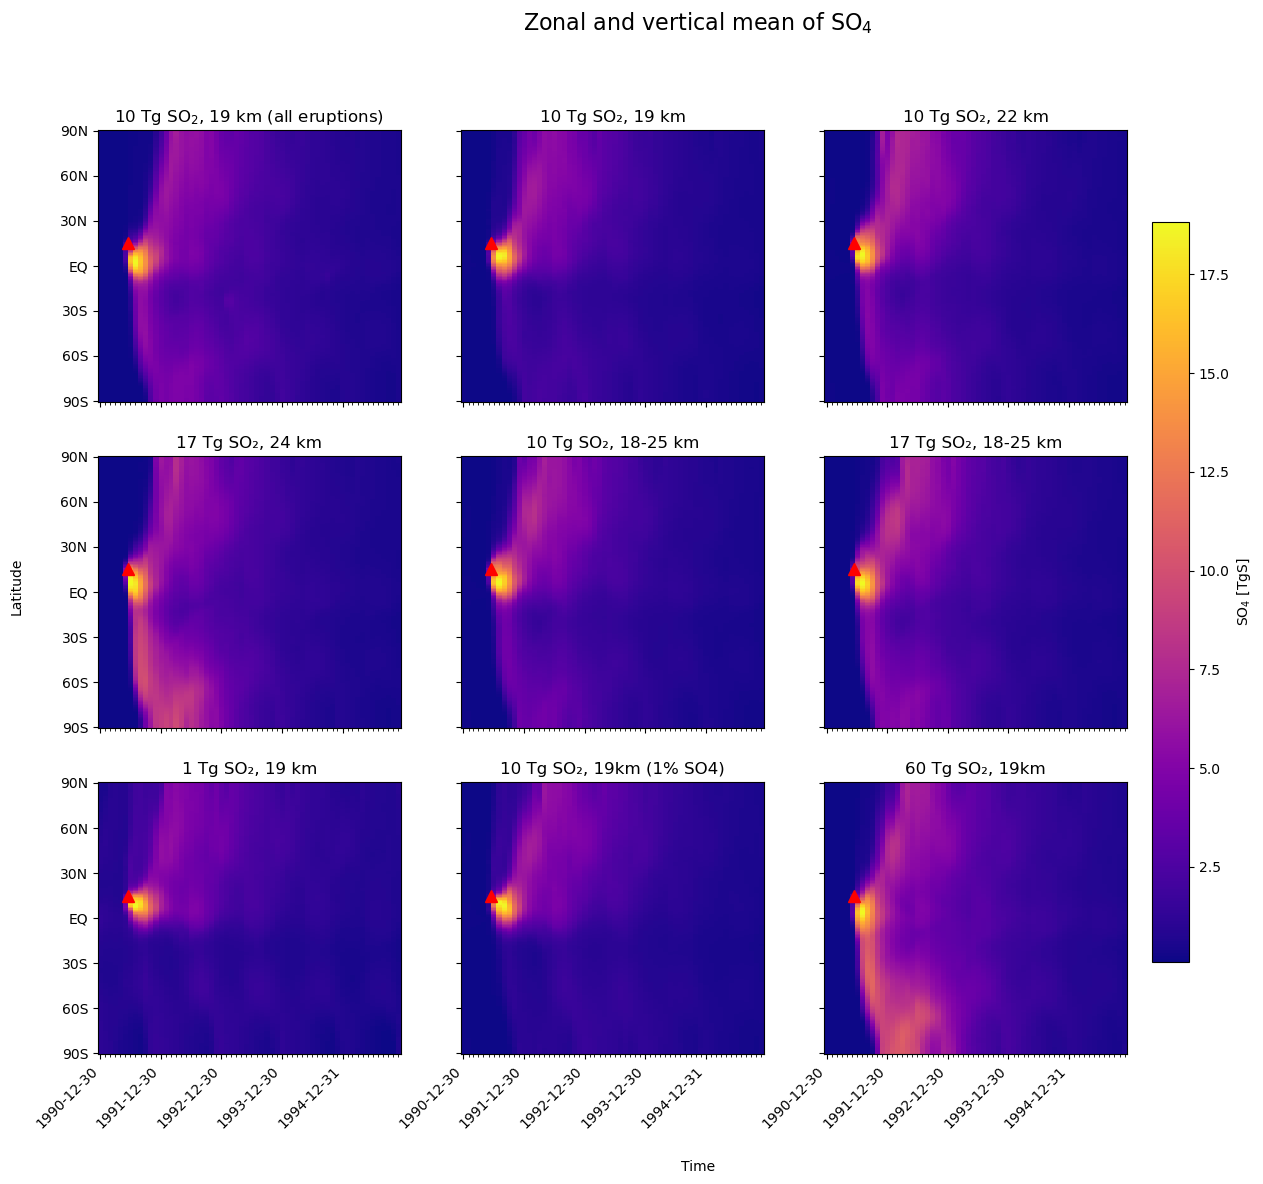

In [48]:
fig, axs = plt.subplots(3, 3, figsize=(16, 12), sharex=True, sharey=True)

datasets = [ds_19, ds_19_c, ds_22, ds_24, ds_1825, ds_1825_17tg, ds_1tg, ds_1pr, ds_60tg]
titles = [
    "10 Tg SO$_2$, 19 km (all eruptions)",
    "10 Tg SO₂, 19 km",
    "10 Tg SO₂, 22 km",
    "17 Tg SO₂, 24 km",
    "10 Tg SO₂, 18-25 km",
    "17 Tg SO₂, 18-25 km",
    "1 Tg SO₂, 19 km",
    "10 Tg SO₂, 19km (1% SO4)",
    "60 Tg SO₂, 19km"
]

for ax, ds, title in zip(axs.flat, datasets, titles):
    plot_so4_lat_time(
        ds,
        ax=ax,
        add_colorbar=False,
        title=title,
    )
    ax.xaxis.set_minor_locator(mdates.MonthLocator(interval=1))
    ax.xaxis.set_major_locator(mdates.YearLocator())


axs[0, 0].set_yticks([-90, -60, -30, 0, 30, 60, 90])
axs[0, 0].set_yticklabels(["90S", "60S", "30S", "EQ", "30N", "60N", "90N"])

fig.colorbar(
    axs.flat[0].collections[0],
    ax=axs,
    label="SO$_4$ [TgS]",
    shrink=0.8,
    pad=0.02,
)


for ax in axs[2, :]:
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

fig.supxlabel('Time', fontsize=10)
fig.supylabel('Latitude', fontsize=10, x=0.07)

fig.suptitle("Zonal and vertical mean of SO$_4$", fontsize=16)
plt.show()

Text(0.5, 1.0, 'Sulphur in form of SO2 and SO4 after Pinatubo')

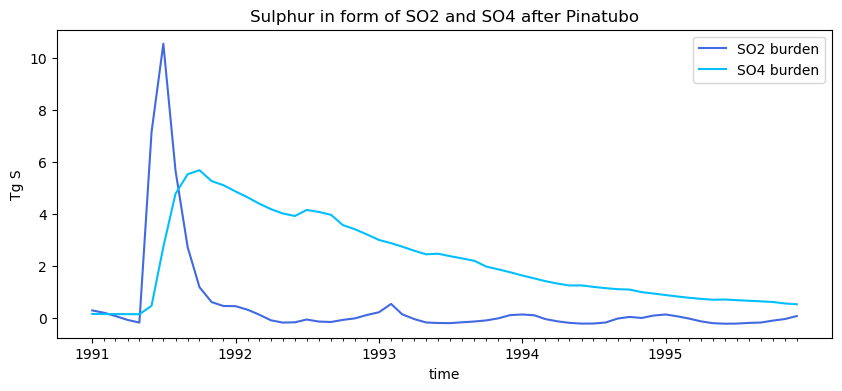

In [56]:
bg = so2_tg.sel(time=[t for t in so2_tg.time.values if 1985 <= t.year <= 1990]).mean(dim="time")
so2_Pinatubo = so2_tg.sel(time=[t for t in so2_tg.time.values if 1991 <= t.year <= 1995])
so2_burden_Pinatubo = so2_Pinatubo - bg

"""background = so4_burden_TgS.sel(time=[t for t in so4_burden_TgS.time.values if 1985 <= t.year <= 1990]).mean(dim="time")
so4_burd_Pinatubo = so4_burden_TgS.sel(time=[t for t in so4_burden_TgS.time.values if 1991 <= t.year <= 1995])
so4_burden_Pinatubo = so4_burd_Pinatubo - background"""

plt.figure(figsize=(10, 4))
so2_burden_Pinatubo.plot(color = "royalblue", label = "SO2 burden")
so4_burd_Pinatubo.plot(color = "deepskyblue", label = "SO4 burden")
years = np.arange(1991, 1996) 
year_ticks = [cftime.DatetimeNoLeap(y, 1, 1) for y in years]
month_ticks = [cftime.DatetimeNoLeap(y, m, 1) for y in years for m in range(1, 13)]
plt.xticks(year_ticks, [str(y) for y in years])
ax = plt.gca()
ax.set_xticks(month_ticks, minor=True)
plt.ylabel("Tg S")
plt.legend()
plt.title("Sulphur in form of SO2 and SO4 after Pinatubo")

<Figure size 700x500 with 0 Axes>

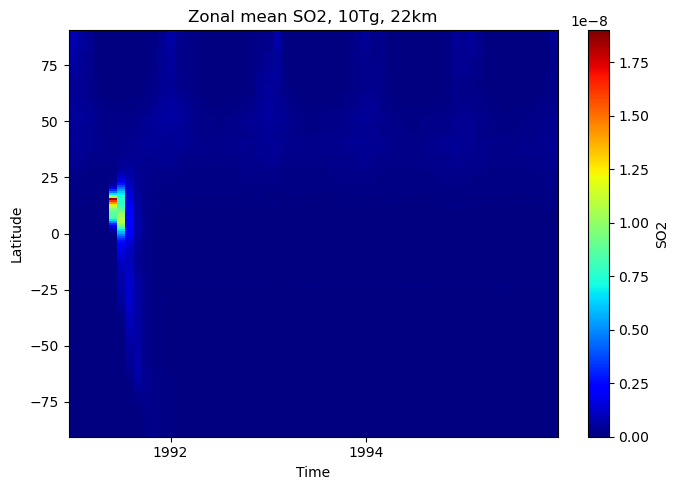

In [57]:
so2 = ds_22["SO2"].weighted(weighted_lat_22).mean(dim="lev")

so2_zoom = so2.sel(time=slice('1991-01-01', '1995-12-01'))
time_zoom = so2_zoom["time"].values

so2_lat_time = so2_zoom.mean(dim="lon")
lat = so2_lat_time["lat"].values

plt.figure(figsize=(7,5))
so2_lat_time.plot.pcolormesh(
    x="time",
    y="lat",
    vmax = 1.9e-8, 
    vmin = 0,
    cmap="jet",
    figsize=(7,5)
)

plt.xlabel("Time")
plt.ylabel("Latitude")
plt.title("Zonal mean SO2, 10Tg, 22km")
plt.tight_layout()
plt.show()

<Figure size 700x500 with 0 Axes>

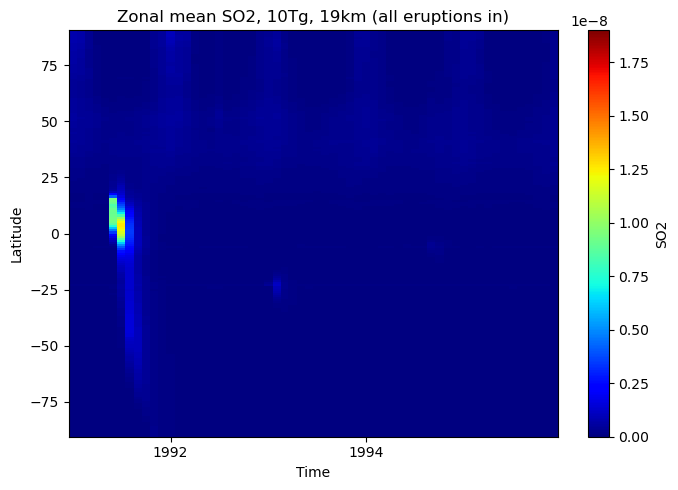

In [58]:
so2 = ds_19["SO2"].weighted(weighted_lat).mean(dim="lev")

so2_zoom = so2.sel(time=slice('1991-01-01', '1995-12-01'))
time_zoom = so2_zoom["time"].values

so2_lat_time = so2_zoom.mean(dim="lon")
lat = so2_lat_time["lat"].values

plt.figure(figsize=(7,5))
so2_lat_time.plot.pcolormesh(
    x="time",
    y="lat",
    vmax = 1.9e-8, 
    vmin = 0,
    cmap="jet",
    figsize=(7,5)
)

plt.xlabel("Time")
plt.ylabel("Latitude")
plt.title("Zonal mean SO2, 10Tg, 19km (all eruptions in)")
plt.tight_layout()
plt.show()

<Figure size 700x500 with 0 Axes>

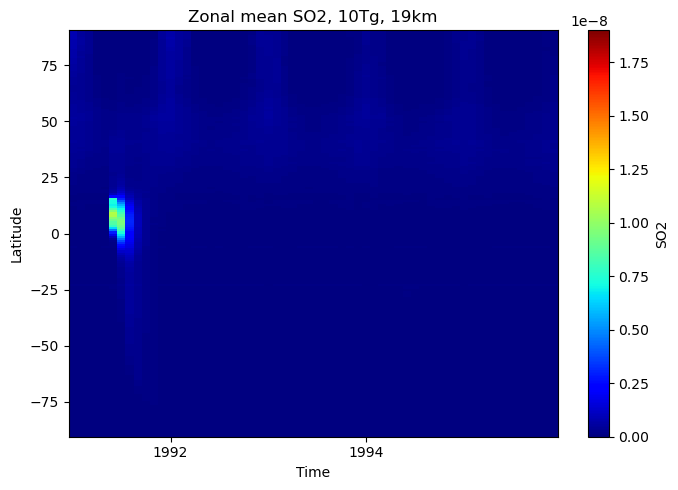

In [59]:
so2 = ds_19_c["SO2"].weighted(weighted_lat_19_c).mean(dim="lev")

so2_zoom = so2.sel(time=slice('1991-01-01', '1995-12-01'))
time_zoom = so2_zoom["time"].values

so2_lat_time = so2_zoom.mean(dim="lon")
lat = so2_lat_time["lat"].values

plt.figure(figsize=(7,5))
so2_lat_time.plot.pcolormesh(
    x="time",
    y="lat",
    vmax = 1.9e-8, 
    vmin = 0,
    cmap="jet",
    figsize=(7,5)
)

plt.xlabel("Time")
plt.ylabel("Latitude")
plt.title("Zonal mean SO2, 10Tg, 19km")
plt.tight_layout()
plt.show()

<Figure size 700x500 with 0 Axes>

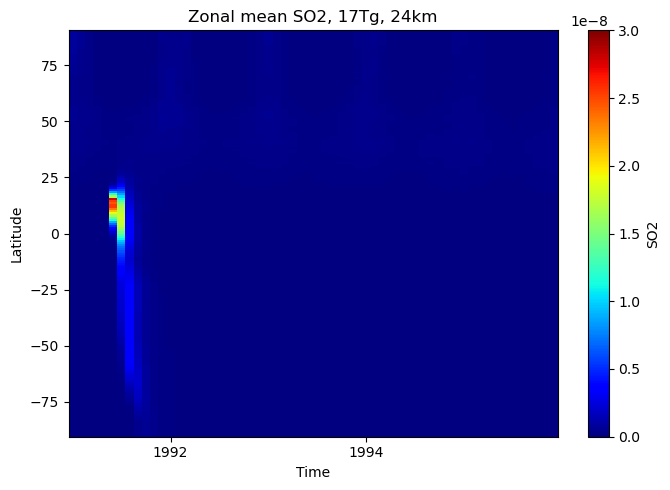

In [60]:
so2 = ds_24["SO2"].weighted(weighted_lat_24).mean(dim="lev")

so2_zoom = so2.sel(time=slice('1991-01-01', '1995-12-01'))
time_zoom = so2_zoom["time"].values

so2_lat_time = so2_zoom.mean(dim="lon")
lat = so2_lat_time["lat"].values

plt.figure(figsize=(7,5))
so2_lat_time.plot.pcolormesh(
    x="time",
    y="lat",
    vmax = 3e-8, 
    vmin = 0,
    cmap="jet",
    figsize=(7,5)
)

plt.xlabel("Time")
plt.ylabel("Latitude")
plt.title("Zonal mean SO2, 17Tg, 24km")
plt.tight_layout()
plt.show()

### AOD

In [92]:
glossac_saod = pd.read_csv(f"{path_obs}/glossac_saod.txt", delim_whitespace=True, header=0,  index_col=0)
avhrr_saod = pd.read_csv(f"{path_obs}/avhrr_saod.txt", delim_whitespace=True, header=0,  index_col=0)

/tmp/ipykernel_1655135/2537514140.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  glossac_saod = pd.read_csv(f"{path_obs}/glossac_saod.txt", delim_whitespace=True, header=0,  index_col=0)
/tmp/ipykernel_1655135/2537514140.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  avhrr_saod = pd.read_csv(f"{path_obs}/avhrr_saod.txt", delim_whitespace=True, header=0,  index_col=0)


In [93]:
start = pd.Timestamp("1991-01-01")
months_glossac = [int(c) for c in glossac_saod.columns]
dates_glossac = [start + pd.DateOffset(months=m) for m in months_glossac]
glossac_saod.columns = dates_glossac

months_avhrr = [int(c) for c in avhrr_saod.columns] 
dates_avhrr = [start + pd.DateOffset(months=m) for m in months_avhrr]
avhrr_saod.columns = dates_avhrr

In [94]:
avhrr_global = avhrr_saod.loc["Global_mean"].astype(float)
glossac_global = glossac_saod.loc["Global_mean"].astype(float)

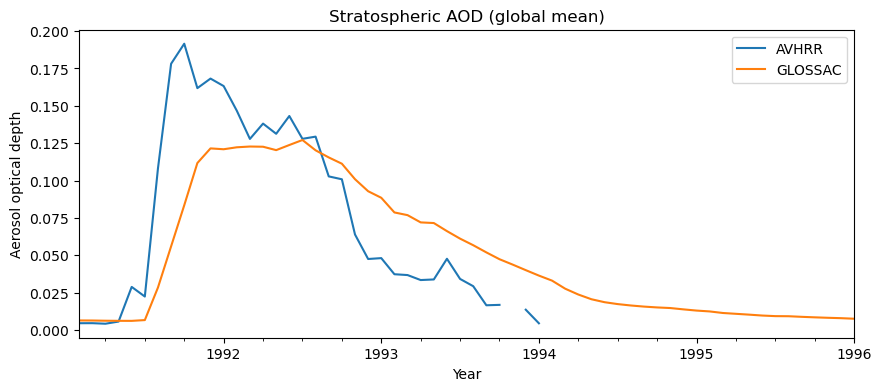

In [95]:
plt.figure(figsize=(10, 4))
avhrr_global.plot(label = "AVHRR")
glossac_global.plot(label="GLOSSAC")
plt.xlabel("Year")
plt.ylabel("Aerosol optical depth")
plt.title("Stratospheric AOD (global mean)")
plt.legend()
plt.show()

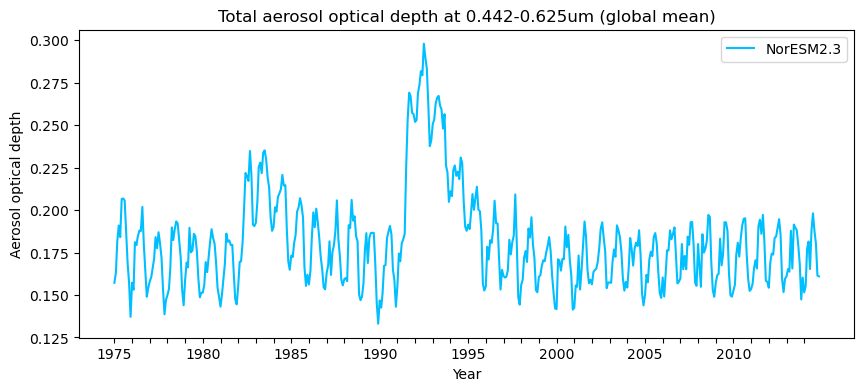

In [96]:
aod500 = "AOD_VIS"  # AOD at 0.442-0.625um
daylight = "DAYFOC"  # Fraction of day in the month

ts_aod = ds_19[aod500].weighted(weighted_lat).mean(dim=["lat", "lon"])
daylight_monthly = ds_19[daylight].weighted(weighted_lat).mean(dim=["lat", "lon"])
ts_aod = ts_aod / daylight_monthly
#ts_aod = ts_aod.resample(time="1YE").mean()
ts_aod_22 = ds_22[aod500].weighted(weighted_lat_22).mean(dim=["lat", "lon"])
daylight_monthly_22 = ds_22[daylight].weighted(weighted_lat_22).mean(dim=["lat", "lon"])
ts_aod_22 = ts_aod_22 / daylight_monthly_22
ts_aod_19_c = ds_19_c[aod500].weighted(weighted_lat_19_c).mean(dim=["lat", "lon"])
daylight_monthly_19_c = ds_19_c[daylight].weighted(weighted_lat_19_c).mean(dim=["lat", "lon"])
ts_aod_19_c = ts_aod_19_c / daylight_monthly_19_c
ts_aod_24 = ds_24[aod500].weighted(weighted_lat_24).mean(dim=["lat", "lon"])
daylight_monthly_24= ds_24[daylight].weighted(weighted_lat_24).mean(dim=["lat", "lon"])
ts_aod_24 = ts_aod_24 / daylight_monthly_24
ts_aod_1825 = ds_1825[aod500].weighted(weighted_lat_1825).mean(dim=["lat", "lon"])
daylight_monthly_1825= ds_1825[daylight].weighted(weighted_lat_1825).mean(dim=["lat", "lon"])
ts_aod_1825 = ts_aod_1825 / daylight_monthly_1825
ts_aod_1825_17tg = ds_1825_17tg[aod500].weighted(weighted_lat_1825_17tg).mean(dim=["lat", "lon"])
daylight_monthly_1825_17tg= ds_1825_17tg[daylight].weighted(weighted_lat_1825_17tg).mean(dim=["lat", "lon"])
ts_aod_1825_17tg = ts_aod_1825_17tg / daylight_monthly_1825_17tg
ts_aod_1tg = ds_1tg[aod500].weighted(weighted_lat_1tg).mean(dim=["lat", "lon"])
daylight_monthly_1tg= ds_1tg[daylight].weighted(weighted_lat_1tg).mean(dim=["lat", "lon"])
ts_aod_1tg = ts_aod_1tg / daylight_monthly_1tg
ts_aod_1pr = ds_1pr[aod500].weighted(weighted_lat_1pr).mean(dim=["lat", "lon"])
daylight_monthly_1pr= ds_1pr[daylight].weighted(weighted_lat_1pr).mean(dim=["lat", "lon"])
ts_aod_1pr = ts_aod_1pr / daylight_monthly_1pr
ts_aod_60tg = ds_60tg[aod500].weighted(weighted_lat_60tg).mean(dim=["lat", "lon"])
daylight_monthly_60tg= ds_60tg[daylight].weighted(weighted_lat_60tg).mean(dim=["lat", "lon"])
ts_aod_60tg = ts_aod_60tg / daylight_monthly_60tg

plt.figure(figsize=(10, 4))
ts_aod.plot(color = "deepskyblue", label = "NorESM2.3")
years = np.arange(1975, 2015)  
year_ticks = [cftime.DatetimeNoLeap(int(y), 1, 1) for y in years]
plt.xticks(year_ticks, [str(y) if y % 5 == 0 else '' for y in years])
plt.xlabel("Year")
plt.ylabel("Aerosol optical depth")
plt.title("Total aerosol optical depth at 0.442-0.625um (global mean)")
plt.legend()
plt.show()


In [97]:
aod_trop = ds_19[aod500].sel(lat=slice(-20,20))
ts_aod_trop = aod_trop.weighted(weighted_lat).mean(dim=["lat", "lon"])
daylight_trop = ds_19[daylight].sel(lat=slice(-20,20))
daylight_monthly_trop = daylight_trop.weighted(weighted_lat).mean(dim=["lat", "lon"])
ts_aod_trop = ts_aod_trop / daylight_monthly_trop

aod_19_c_trop = ds_19_c[aod500].sel(lat=slice(-20,20))
ts_aod_19_c_trop = aod_19_c_trop.weighted(weighted_lat_19_c).mean(dim=["lat", "lon"])
daylight_19_c_trop = ds_19_c[daylight].sel(lat=slice(-20,20))
daylight_monthly_19_c_trop = daylight_19_c_trop.weighted(weighted_lat_19_c).mean(dim=["lat", "lon"])
ts_aod_19_c_trop = ts_aod_19_c_trop / daylight_monthly_19_c_trop

aod_22_trop = ds_22[aod500].sel(lat=slice(-20,20))
ts_aod_22_trop = aod_22_trop.weighted(weighted_lat_22).mean(dim=["lat", "lon"])
daylight_22_trop = ds_22[daylight].sel(lat=slice(-20,20))
daylight_monthly_22_trop = daylight_22_trop.weighted(weighted_lat_22).mean(dim=["lat", "lon"])
ts_aod_22_trop = ts_aod_22_trop / daylight_monthly_22_trop

aod_24_trop = ds_24[aod500].sel(lat=slice(-20,20))
ts_aod_24_trop = aod_24_trop.weighted(weighted_lat_24).mean(dim=["lat", "lon"])
daylight_24_trop = ds_24[daylight].sel(lat=slice(-20,20))
daylight_monthly_24_trop = daylight_24_trop.weighted(weighted_lat_24).mean(dim=["lat", "lon"])
ts_aod_24_trop = ts_aod_24_trop / daylight_monthly_24_trop

aod_1825_trop = ds_1825[aod500].sel(lat=slice(-20,20))
ts_aod_1825_trop = aod_1825_trop.weighted(weighted_lat_1825).mean(dim=["lat", "lon"])
daylight_1825_trop = ds_1825[daylight].sel(lat=slice(-20,20))
daylight_monthly_1825_trop = daylight_1825_trop.weighted(weighted_lat_1825).mean(dim=["lat", "lon"])
ts_aod_1825_trop = ts_aod_1825_trop / daylight_monthly_1825_trop

aod_1825_17tg_trop = ds_1825_17tg[aod500].sel(lat=slice(-20,20))
ts_aod_1825_17tg_trop = aod_1825_17tg_trop.weighted(weighted_lat_1825_17tg).mean(dim=["lat", "lon"])
daylight_1825_17tg_trop = ds_1825_17tg[daylight].sel(lat=slice(-20,20))
daylight_monthly_1825_17tg_trop = daylight_1825_17tg_trop.weighted(weighted_lat_1825_17tg).mean(dim=["lat", "lon"])
ts_aod_1825_17tg_trop = ts_aod_1825_17tg_trop / daylight_monthly_1825_17tg_trop

aod_1tg_trop = ds_1tg[aod500].sel(lat=slice(-20,20))
ts_aod_1tg_trop = aod_1tg_trop.weighted(weighted_lat_1tg).mean(dim=["lat", "lon"])
daylight_1tg_trop = ds_1tg[daylight].sel(lat=slice(-20,20))
daylight_monthly_1tg_trop = daylight_1tg_trop.weighted(weighted_lat_1tg).mean(dim=["lat", "lon"])
ts_aod_1tg_trop = ts_aod_1tg_trop / daylight_monthly_1tg_trop

aod_1pr_trop = ds_1pr[aod500].sel(lat=slice(-20,20))
ts_aod_1pr_trop = aod_1pr_trop.weighted(weighted_lat_1pr).mean(dim=["lat", "lon"])
daylight_1pr_trop = ds_1pr[daylight].sel(lat=slice(-20,20))
daylight_monthly_1pr_trop = daylight_1pr_trop.weighted(weighted_lat_1pr).mean(dim=["lat", "lon"])
ts_aod_1pr_trop = ts_aod_1pr_trop / daylight_monthly_1pr_trop

aod_60tg_trop = ds_60tg[aod500].sel(lat=slice(-20,20))
ts_aod_60tg_trop = aod_60tg_trop.weighted(weighted_lat_60tg).mean(dim=["lat", "lon"])
daylight_60tg_trop = ds_60tg[daylight].sel(lat=slice(-20,20))
daylight_monthly_60tg_trop = daylight_60tg_trop.weighted(weighted_lat_60tg).mean(dim=["lat", "lon"])
ts_aod_60tg_trop = ts_aod_60tg_trop / daylight_monthly_60tg_trop

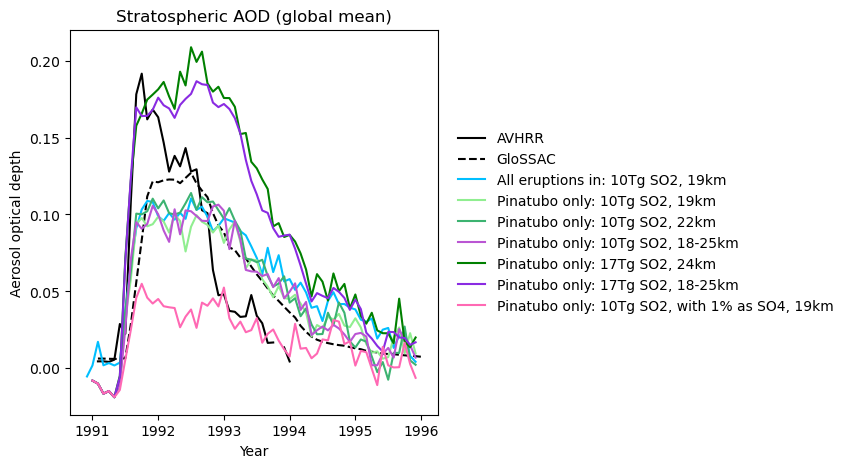

In [98]:
pre_eruption = ts_aod.sel(time=slice("1976-01", "1981-12"))
base = pre_eruption.groupby("time.month").mean("time")
aod_anom = ts_aod.groupby("time.month") - base
aod_anom_22 = ts_aod_22.groupby("time.month") - base
aod_anom_19_c = ts_aod_19_c.groupby("time.month") - base
aod_anom_24 = ts_aod_24.groupby("time.month") - base
aod_anom_1825 = ts_aod_1825.groupby("time.month") - base
aod_anom_1825_17tg = ts_aod_1825_17tg.groupby("time.month") - base
aod_anom_1tg = ts_aod_1tg.groupby("time.month") - base
aod_anom_1pr = ts_aod_1pr.groupby("time.month") - base
aod_anom_60tg = ts_aod_60tg.groupby("time.month") - base
aod_Pinatubo = aod_anom.sel(time=slice("1990-12", "1995-12"))
aod_smooth = aod_Pinatubo.rolling(time=1, center=True).mean()

obs_time_avhrr = np.array([t.year + (t.month-1)/12 for t in avhrr_global.index])
obs_time_glossac = np.array([t.year + (t.month-1)/12 for t in glossac_global.index])
time_years = np.array([t.year + (t.month-1)/12 for t in aod_Pinatubo.time.values])
time_years_22 = np.array([t.year + (t.month-1)/12 for t in aod_anom_22.time.values])
time_years_19_c = np.array([t.year + (t.month-1)/12 for t in aod_anom_19_c.time.values])
time_years_24 = np.array([t.year + (t.month-1)/12 for t in aod_anom_24.time.values])
time_years_1825 = np.array([t.year + (t.month-1)/12 for t in aod_anom_1825.time.values])
time_years_1825_17tg = np.array([t.year + (t.month-1)/12 for t in aod_anom_1825_17tg.time.values])
time_years_1tg = np.array([t.year + (t.month-1)/12 for t in aod_anom_1tg.time.values])
time_years_1pr = np.array([t.year + (t.month-1)/12 for t in aod_anom_1pr.time.values])
time_years_60tg = np.array([t.year + (t.month-1)/12 for t in aod_anom_60tg.time.values])

plt.figure(figsize=(7, 5))
plt.plot(obs_time_avhrr, avhrr_global, color = "black", label = "AVHRR")
plt.plot(obs_time_glossac, glossac_global, color = "black", linestyle="--", label = "GloSSAC")
plt.plot(time_years, aod_Pinatubo, color = "deepskyblue", label = "All eruptions in: 10Tg SO2, 19km")
plt.plot(time_years_19_c, aod_anom_19_c, color = "lightgreen", label = "Pinatubo only: 10Tg SO2, 19km")
plt.plot(time_years_22, aod_anom_22, color = "mediumseagreen", label = "Pinatubo only: 10Tg SO2, 22km")
plt.plot(time_years_1825, aod_anom_1825, color = "mediumorchid", label = "Pinatubo only: 10Tg SO2, 18-25km")
plt.plot(time_years_24, aod_anom_24, color = "green", label = "Pinatubo only: 17Tg SO2, 24km")
plt.plot(time_years_1825_17tg, aod_anom_1825_17tg, color = "blueviolet", label = "Pinatubo only: 17Tg SO2, 18-25km")
#plt.plot(time_years_1tg, aod_anom_1tg, color = "orange", label = "Pinatubo only: 1Tg SO2, 19km")
plt.plot(time_years_1pr, aod_anom_1pr, color = "hotpink", label = "Pinatubo only: 10Tg SO2, with 1% as SO4, 19km")
#plt.plot(time_years_60tg, aod_anom_60tg, color = "cornflowerblue", label = "Pinatubo only: 60Tg SO2, 19km")
plt.xlabel("Year")
plt.ylabel("Aerosol optical depth")
plt.title("Stratospheric AOD (global mean)")
fig = plt.gcf()
ax = plt.gca()

fig.subplots_adjust(right=0.65)

ax.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False
)

plt.show()

In [99]:
pre_eruption_trop = ts_aod_trop.sel(time=slice("1976-01", "1981-12"))
base_trop = pre_eruption_trop.groupby("time.month").mean("time")
aod_anom_trop = ts_aod_trop.groupby("time.month") - base_trop
aod_anom_22_trop = ts_aod_22_trop.groupby("time.month") - base_trop
aod_anom_19_c_trop = ts_aod_19_c_trop.groupby("time.month") - base_trop
aod_anom_24_trop = ts_aod_24_trop.groupby("time.month") - base_trop
aod_anom_1825_trop = ts_aod_1825_trop.groupby("time.month") - base_trop
aod_anom_1825_17tg_trop = ts_aod_1825_17tg_trop.groupby("time.month") - base_trop
aod_anom_1tg_trop = ts_aod_1tg_trop.groupby("time.month") - base_trop
aod_anom_1pr_trop = ts_aod_1pr_trop.groupby("time.month") - base_trop
aod_anom_60tg_trop = ts_aod_60tg_trop.groupby("time.month") - base_trop
aod_Pinatubo_trop = aod_anom_trop.sel(time=slice("1990-12", "1995-12"))

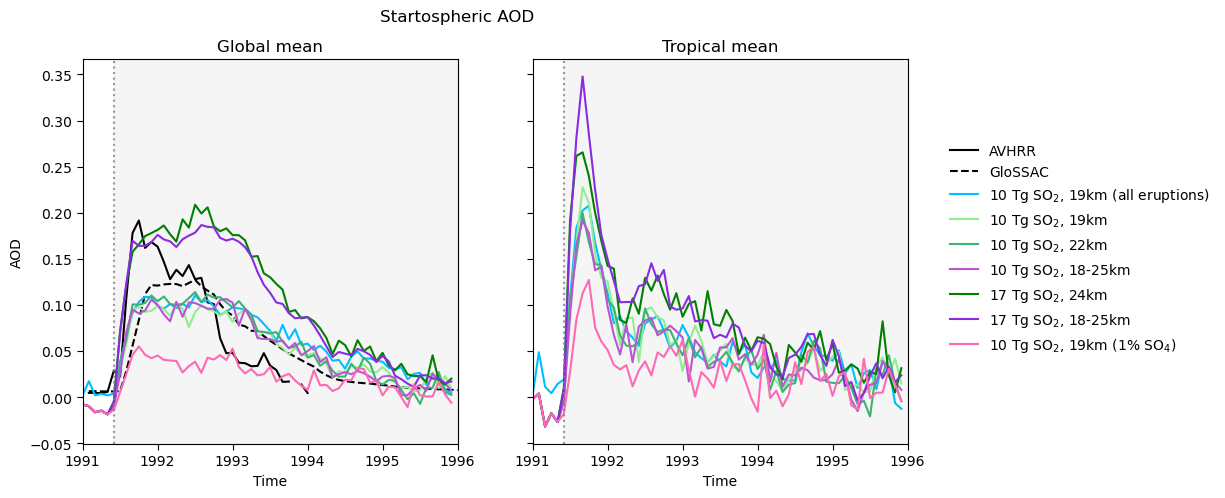

In [100]:
eruption_date=cftime.DatetimeNoLeap(1991, 6, 1)
time_years_trop = np.array([t.year + (t.month-1)/12 for t in aod_Pinatubo_trop.time.values])
time_years_22_trop = np.array([t.year + (t.month-1)/12 for t in aod_anom_22_trop.time.values])
time_years_19_c_trop = np.array([t.year + (t.month-1)/12 for t in aod_anom_19_c_trop.time.values])
time_years_24_trop = np.array([t.year + (t.month-1)/12 for t in aod_anom_24_trop.time.values])
time_years_1825_trop = np.array([t.year + (t.month-1)/12 for t in aod_anom_1825_trop.time.values])
time_years_1825_17tg_trop = np.array([t.year + (t.month-1)/12 for t in aod_anom_1825_17tg_trop.time.values])
time_years_1tg_trop = np.array([t.year + (t.month-1)/12 for t in aod_anom_1tg_trop.time.values])
time_years_1pr_trop = np.array([t.year + (t.month-1)/12 for t in aod_anom_1pr_trop.time.values])
time_years_60tg_trop= np.array([t.year + (t.month-1)/12 for t in aod_anom_60tg_trop.time.values])

fig, ax = plt.subplots(1, 2, figsize=(10, 5), sharey=True)
ax[0].plot(obs_time_avhrr, avhrr_global, color = "black", label = "AVHRR")
ax[0].plot(obs_time_glossac, glossac_global, color = "black", linestyle="--", label = "GloSSAC")
ax[0].plot(time_years, aod_Pinatubo, color = "deepskyblue", label = "10 Tg SO$_2$, 19km (all eruptions)")
ax[0].plot(time_years_19_c, aod_anom_19_c, color = "lightgreen", label = "10 Tg SO$_2$, 19km")
ax[0].plot(time_years_22, aod_anom_22, color = "mediumseagreen", label = "10 Tg SO$_2$, 22km")
ax[0].plot(time_years_1825, aod_anom_1825, color = "mediumorchid", label = "10 Tg SO$_2$, 18-25km")
ax[0].plot(time_years_24, aod_anom_24, color = "green", label = "17 Tg SO$_2$, 24km")
ax[0].plot(time_years_1825_17tg, aod_anom_1825_17tg, color = "blueviolet", label = "17 Tg SO$_2$, 18-25km")
#ax[0].plot(aod_anom_1tg.time, aod_anom_1tg, color="orange", label="1 Tg SO2, 19km")
ax[0].plot(time_years_1pr, aod_anom_1pr, color="hotpink", label="10 Tg SO$_2$, 19km (1% SO$_4$)")
#ax[0].plot(aod_anom_60tg.time, aod_anom_60tg, color="cornflowerblue", label="60 Tg SO2, 19km")
ax[0].set_ylabel("AOD")
ax[0].set_xlabel("Time")
ax[0].set_title("Global mean")

ax[1].plot(time_years_trop, aod_Pinatubo_trop, color = "deepskyblue", label = "10 Tg, 19 km (all eruptions)")
ax[1].plot(time_years_19_c_trop, aod_anom_19_c_trop, color = "lightgreen", label = "10 Tg SO$_2$, 19km")
ax[1].plot(time_years_22_trop, aod_anom_22_trop, color = "mediumseagreen", label = "10 Tg SO$_2$, 22km")
ax[1].plot(time_years_1825_trop, aod_anom_1825_trop, color = "mediumorchid", label = "10 Tg SO$_2$, 18-25km")
ax[1].plot(time_years_24_trop, aod_anom_24_trop, color = "green", label = "17 Tg SO$_2$, 24km")
ax[1].plot(time_years_1825_17tg_trop, aod_anom_1825_17tg_trop, color = "blueviolet", label = "17 Tg SO$_2$, 18-25km")
#ax[1].plot(aod_anom_1tg_trop.time, aod_anom_1tg_trop, color="orange", label="1 Tg SO2, 19km")
ax[1].plot(time_years_1pr_trop, aod_anom_1pr_trop, color="hotpink", label="10 Tg SO$_2$, 19km (1% SO$_4$)")
#ax[1].plot(aod_anom_60tg_trop.time, aod_anom_60tg_trop, color="cornflowerblue", label="60 Tg SO2, 19km")
ax[1].set_xlabel("Time")
ax[1].set_title("Tropical mean")

eruption_float = 1991 + (6-1)/12  
end_float = 1996 + (1-1)/12     

for i, a in enumerate(ax):
    a.axvline(eruption_float, color='gray', ls=":", alpha=0.8)
    a.axvspan(eruption_float, end_float, color='gray', alpha=0.08, zorder=0)
    
    a.set_xlim(1991, 1996) 
    a.set_xticks([1991, 1992, 1993, 1994, 1995, 1996])
    a.set_xticklabels(["1991", "1992", "1993", "1994", "1995", "1996"])
    
    a.tick_params(direction='out', length=4)
    

handles, labels = ax[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="center left",
    bbox_to_anchor=(0.98, 0.5),
    frameon=False
)

fig.suptitle("Startospheric AOD")
fig.subplots_adjust(right=0.95)
plt.show()

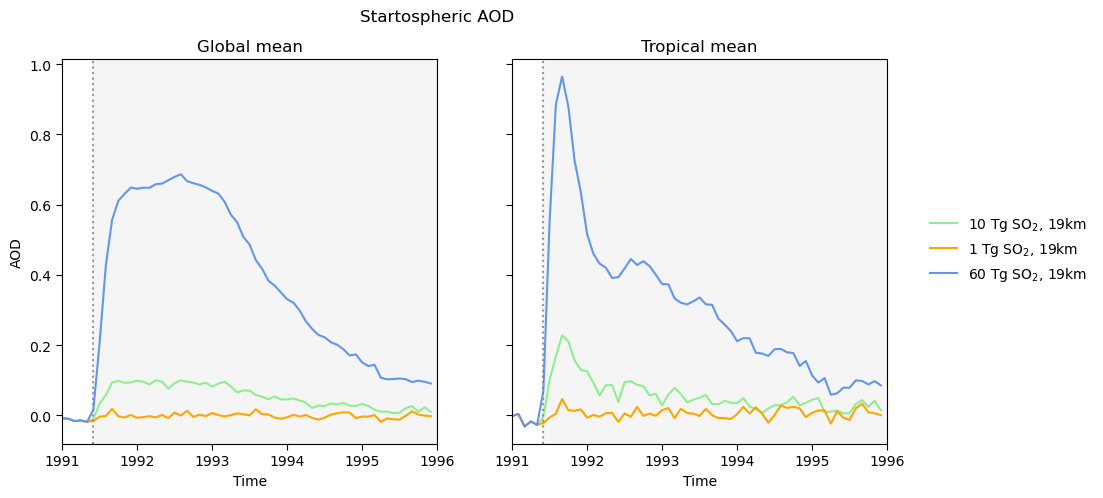

In [101]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5), sharey=True)
#ax[0].plot(aod_Pinatubo.time, aod_Pinatubo, color = "deepskyblue", label = "10 Tg SO$_2$, 19km (all eruptions)")
ax[0].plot(time_years_19_c, aod_anom_19_c, color = "lightgreen", label = "10 Tg SO$_2$, 19km")
ax[0].plot(time_years_1tg, aod_anom_1tg, color="orange", label="1 Tg SO$_2$, 19km")
ax[0].plot(time_years_60tg, aod_anom_60tg, color="cornflowerblue", label="60 Tg SO$_2$, 19km")
ax[0].set_ylabel("AOD")
ax[0].set_xlabel("Time")
ax[0].set_title("Global mean")

#ax[1].plot(aod_Pinatubo_trop.time, aod_Pinatubo_trop, color = "deepskyblue", label = "10 Tg, 19 km (all eruptions)")
ax[1].plot(time_years_19_c_trop, aod_anom_19_c_trop, color = "lightgreen", label = "10 Tg SO$_2$, 19km")
ax[1].plot(time_years_1tg_trop, aod_anom_1tg_trop, color="orange", label="1 Tg SO$_2$, 19km")
ax[1].plot(time_years_60tg_trop, aod_anom_60tg_trop, color="cornflowerblue", label="60 Tg SO$_2$, 19km")
ax[1].set_xlabel("Time")
ax[1].set_title("Tropical mean")

eruption_float = 1991 + (6-1)/12  
end_float = 1996 + (1-1)/12     

for i, a in enumerate(ax):
    a.axvline(eruption_float, color='gray', ls=":", alpha=0.8)
    a.axvspan(eruption_float, end_float, color='gray', alpha=0.08, zorder=0)
    
    a.set_xlim(1991, 1996) 
    a.set_xticks([1991, 1992, 1993, 1994, 1995, 1996])
    a.set_xticklabels(["1991", "1992", "1993", "1994", "1995", "1996"])
    
    a.tick_params(direction='out', length=4)
    

handles, labels = ax[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="center left",
    bbox_to_anchor=(0.98, 0.5),
    frameon=False
)

fig.suptitle("Startospheric AOD")
fig.subplots_adjust(right=0.95)
plt.show()

In [79]:
aod_19 = ds_19[aod500]
daylight_monthly_nw_19 = ds_19[daylight]
aod_19 = aod_19 / daylight_monthly_nw_19

baseline = aod_19.sel(time=slice("1976-01", "1981-12"))
base = baseline.groupby("time.month").mean("time")
aod_strat_19 = aod_19.groupby("time.month") - base

aod_zoom_19 = aod_strat_19.sel(time=slice('1991-01-01', '1994-01-01'))
time_zoom_19 = aod_zoom_19['time'].values
aod_lat_time_19 = aod_zoom_19.mean(dim="lon")
lat_19 = aod_lat_time_19["lat"]


In [80]:
aod_22 = ds_22[aod500]
daylight_monthly_nw_22 = ds_22[daylight]
aod_22 = aod_22 / daylight_monthly_nw_22
aod_strat_22 = aod_22.groupby("time.month") - base

aod_zoom_22 = aod_strat_22.sel(time=slice('1991-01-01', '1994-01-01'))
time_zoom_22 = aod_zoom_22['time'].values
aod_lat_time_22 = aod_zoom_22.mean(dim="lon")
lat_22 = aod_lat_time_22["lat"]

In [81]:
aod_19_c = ds_19_c[aod500]
daylight_monthly_nw_19_c = ds_19_c[daylight]
aod_19_c = aod_19_c / daylight_monthly_nw_19_c
aod_strat_19_c = aod_19_c.groupby("time.month") - base

aod_zoom_19_c = aod_strat_19_c.sel(time=slice('1991-01-01', '1994-01-01'))
time_zoom_19_c = aod_zoom_19_c['time'].values
aod_lat_time_19_c = aod_zoom_19_c.mean(dim="lon")
lat_19_c = aod_lat_time_19_c["lat"]

In [82]:
aod_24 = ds_24[aod500]
daylight_monthly_nw_24 = ds_24[daylight]
aod_24 = aod_24 / daylight_monthly_nw_24
aod_strat_24= aod_24.groupby("time.month") - base

aod_zoom_24 = aod_strat_24.sel(time=slice('1991-01-01', '1994-01-01'))
time_zoom_24 = aod_zoom_24['time'].values
aod_lat_time_24 = aod_zoom_24.mean(dim="lon")
lat_24 = aod_lat_time_24["lat"]

In [83]:
aod_1825 = ds_1825[aod500]
daylight_monthly_nw_1825 = ds_1825[daylight]
aod_1825 = aod_1825 / daylight_monthly_nw_1825
aod_strat_1825= aod_1825.groupby("time.month") - base

aod_zoom_1825 = aod_strat_1825.sel(time=slice('1991-01-01', '1994-01-01'))
time_zoom_1825 = aod_zoom_1825['time'].values
aod_lat_time_1825 = aod_zoom_1825.mean(dim="lon")
lat_1825 = aod_lat_time_1825["lat"]

In [84]:
aod_1825_17tg = ds_1825_17tg[aod500]
daylight_monthly_nw_1825_17tg = ds_1825_17tg[daylight]
aod_1825_17tg = aod_1825_17tg / daylight_monthly_nw_1825_17tg
aod_strat_1825_17tg= aod_1825_17tg.groupby("time.month") - base

aod_zoom_1825_17tg = aod_strat_1825_17tg.sel(time=slice('1991-01-01', '1994-01-01'))
time_zoom_1825_17tg = aod_zoom_1825_17tg['time'].values
aod_lat_time_1825_17tg = aod_zoom_1825_17tg.mean(dim="lon")
lat_1825_17tg = aod_lat_time_1825_17tg["lat"]

In [85]:
aod_1tg = ds_1tg[aod500]
daylight_monthly_nw_1tg = ds_1tg[daylight]
aod_1tg = aod_1tg / daylight_monthly_nw_1tg
aod_strat_1tg= aod_1tg.groupby("time.month") - base

aod_zoom_1tg = aod_strat_1tg.sel(time=slice('1991-01-01', '1994-01-01'))
time_zoom_1tg = aod_zoom_1tg['time'].values
aod_lat_time_1tg = aod_zoom_1tg.mean(dim="lon")
lat_1tg = aod_lat_time_1tg["lat"]

In [86]:
aod_1pr = ds_1pr[aod500]
daylight_monthly_nw_1pr = ds_1pr[daylight]
aod_1pr = aod_1pr/ daylight_monthly_nw_1pr
aod_strat_1pr= aod_1pr.groupby("time.month") - base

aod_zoom_1pr = aod_strat_1pr.sel(time=slice('1991-01-01', '1994-01-01'))
time_zoom_1pr = aod_zoom_1pr['time'].values
aod_lat_time_1pr = aod_zoom_1pr.mean(dim="lon")
lat_1pr = aod_lat_time_1pr["lat"]

In [87]:
aod_60tg = ds_60tg[aod500]
daylight_monthly_nw_60tg = ds_60tg[daylight]
aod_60tg = aod_60tg/ daylight_monthly_nw_60tg
aod_strat_60tg= aod_60tg.groupby("time.month") - base

aod_zoom_60tg = aod_strat_60tg.sel(time=slice('1991-01-01', '1994-01-01'))
time_zoom_60tg = aod_zoom_60tg['time'].values
aod_lat_time_60tg = aod_zoom_60tg.mean(dim="lon")
lat_60tg = aod_lat_time_60tg["lat"]

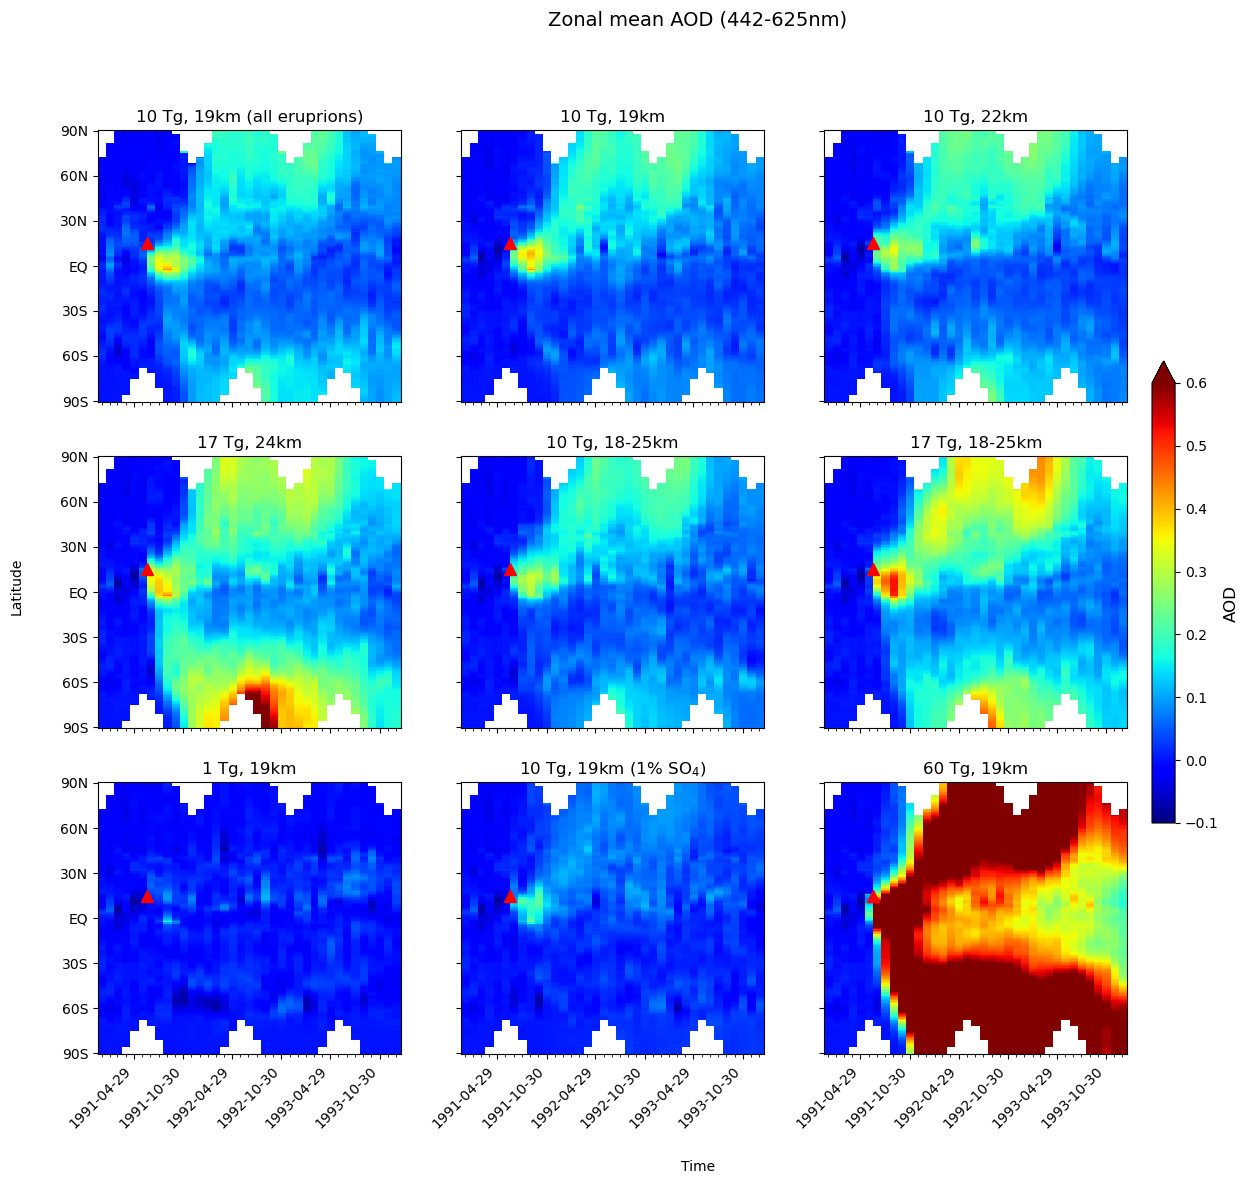

In [88]:
all_aod_lat = [aod_lat_time_19, aod_lat_time_19_c, aod_lat_time_22, aod_lat_time_24, aod_lat_time_1825, 
           aod_lat_time_1825_17tg, aod_lat_time_1tg, aod_lat_time_1pr, aod_lat_time_60tg]

all_times = [time_zoom_19, time_zoom_19_c, time_zoom_22, time_zoom_24, time_zoom_1825, 
             time_zoom_1825_17tg, time_zoom_1tg, time_zoom_1pr, time_zoom_60tg]

all_lat = [lat_19, lat_19_c, lat_22, lat_24, lat_1825, 
             lat_1825_17tg, lat_1tg, lat_1pr, lat_60tg]

titles = ["10 Tg, 19km (all eruprions)", "10 Tg, 19km", "10 Tg, 22km", "17 Tg, 24km", 
          "10 Tg, 18-25km", "17 Tg, 18-25km", "1 Tg, 19km", 
          "10 Tg, 19km (1% SO$_4$)", "60 Tg, 19km"]

fig, axs = plt.subplots(3, 3, figsize=(16, 12), sharex=True, sharey=True)

for i, ax in enumerate(axs.flat):
    if i < len(all_aod_lat):
        pc = ax.pcolormesh(all_times[i], all_lat[i], all_aod_lat[i].T, 
                         vmax = 0.6, vmin = -0.1, shading="auto", cmap="jet")
        
        ax.plot(
            cftime.DatetimeNoLeap(1991, 6, 15),
            15,
            marker="^",
            color="red",
            markersize=9,
            zorder=5,
        )
        
        ax.set_title(titles[i], fontsize=12)
        ax.xaxis.set_minor_locator(mdates.MonthLocator(interval=1))
        ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))

axs[0, 0].set_yticks([-90, -60, -30, 0, 30, 60, 90])
axs[0, 0].set_yticklabels(["90S", "60S", "30S", "EQ", "30N", "60N", "90N"])

if pc:
    cbar = fig.colorbar(pc, ax=axs, location='right', shrink=0.5, pad=0.02, extend='max')
    cbar.set_label("AOD", fontsize=12)

for ax in axs[2, :]:
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

fig.supxlabel('Time', fontsize=10)
fig.supylabel('Latitude', fontsize=10, x=0.07)
fig.suptitle("Zonal mean AOD (442-625nm)", fontsize=14)

plt.tight_layout
plt.show()


## Ozone

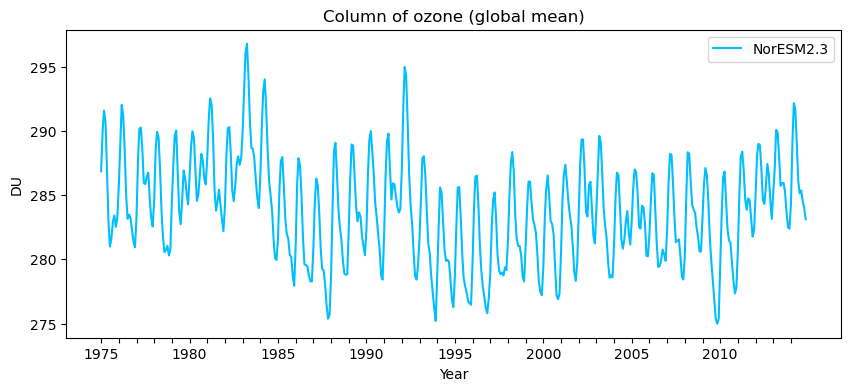

In [102]:
#  1DU = 2.1415e-05 kg/m2
DU = 1.0 / 2.1415e-05
cb_o3 = "cb_O3"

o3 = ds_19[cb_o3].weighted(weighted_lat).mean(dim=["lat", "lon"]) * DU

plt.figure(figsize=(10, 4))
o3.plot(color = "deepskyblue", label = "NorESM2.3")
years = np.arange(1975, 2015)  
year_ticks = [cftime.DatetimeNoLeap(int(y), 1, 1) for y in years]
plt.xticks(year_ticks, [str(y) if y % 5 == 0 else '' for y in years])
plt.xlabel("Year")
plt.ylabel("DU")
plt.title("Column of ozone (global mean)")
plt.legend()
plt.show()

In [103]:
def calc_anomaly(ds, weights, baseline_obj, lat_range=None):
    var = "cb_O3" 
    
    if lat_range:
        data = ds[var].sel(lat=slice(*lat_range))
        w = weights.sel(lat=slice(*lat_range))
    else:
        data = ds[var]
        w = weights
        
    mean_ts = data.weighted(w).mean(dim=["lat", "lon"]) * DU
    anom = mean_ts.groupby("time.month") - baseline_obj
    return anom.sel(time=slice('1991-01-01', '1996-01-01'))

In [ ]:
# Global
o3_glob = ds_19["cb_O3"].weighted(weighted_lat).mean(dim=["lat", "lon"]) * DU
base_global = o3_glob.sel(time=slice("1975", "1990")).groupby("time.month").mean()

# Tropics
o3_trop = ds_19["cb_O3"].sel(lat=slice(-20,20)).weighted(weighted_lat.sel(lat=slice(-20,20))).mean(dim=["lat", "lon"]) * DU
base_trop = o3_trop.sel(time=slice("1975", "1990")).groupby("time.month").mean()

In [105]:
o3_anom = calc_anomaly(ds_19, weighted_lat, base_global)
o3_19_c_anom = calc_anomaly(ds_19, weighted_lat, base_global)
o3_22_anom = calc_anomaly(ds_22, weighted_lat_22, base_global)
o3_24_anom = calc_anomaly(ds_24, weighted_lat_24, base_global)
o3_1825_anom = calc_anomaly(ds_1825, weighted_lat_1825, base_global)
o3_1825_17tg_anom = calc_anomaly(ds_1825_17tg, weighted_lat_1825_17tg, base_global)
o3_1pr_anom = calc_anomaly(ds_1pr, weighted_lat_1pr, base_global)
o3_1tg_anom = calc_anomaly(ds_1tg, weighted_lat_1tg, base_global)
o3_60tg_anom = calc_anomaly(ds_60tg, weighted_lat_60tg, base_global)

In [106]:
o3_anom_trop = calc_anomaly(ds_19, weighted_lat, base_trop, lat_range=(-20,20))
o3_19_c_anom_trop = calc_anomaly(ds_19, weighted_lat, base_trop, lat_range=(-20,20))
o3_22_anom_trop = calc_anomaly(ds_22, weighted_lat_22, base_trop, lat_range=(-20,20))
o3_24_anom_trop = calc_anomaly(ds_24, weighted_lat_24, base_trop, lat_range=(-20,20))
o3_1825_anom_trop = calc_anomaly(ds_1825, weighted_lat_1825, base_trop, lat_range=(-20,20))
o3_1825_17tg_anom_trop = calc_anomaly(ds_1825_17tg, weighted_lat_1825_17tg, base_trop, lat_range=(-20,20))
o3_1pr_anom_trop = calc_anomaly(ds_1pr, weighted_lat_1pr, base_trop, lat_range=(-20,20))
o3_1tg_anom_trop = calc_anomaly(ds_1tg, weighted_lat_1tg, base_trop, lat_range=(-20,20))
o3_60tg_anom_trop = calc_anomaly(ds_60tg, weighted_lat_60tg, base_trop, lat_range=(-20,20))

In [108]:
o3_anom

<xarray.DataArray 'cb_O3' (time: 61)> Size: 488B
dask.array<getitem, shape=(61,), dtype=float64, chunksize=(1,), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) object 488B 1991-01-01 00:00:00 ... 1996-01-01 00:00:00
    month    (time) int64 488B 1 2 3 4 5 6 7 8 9 10 ... 4 5 6 7 8 9 10 11 12 1

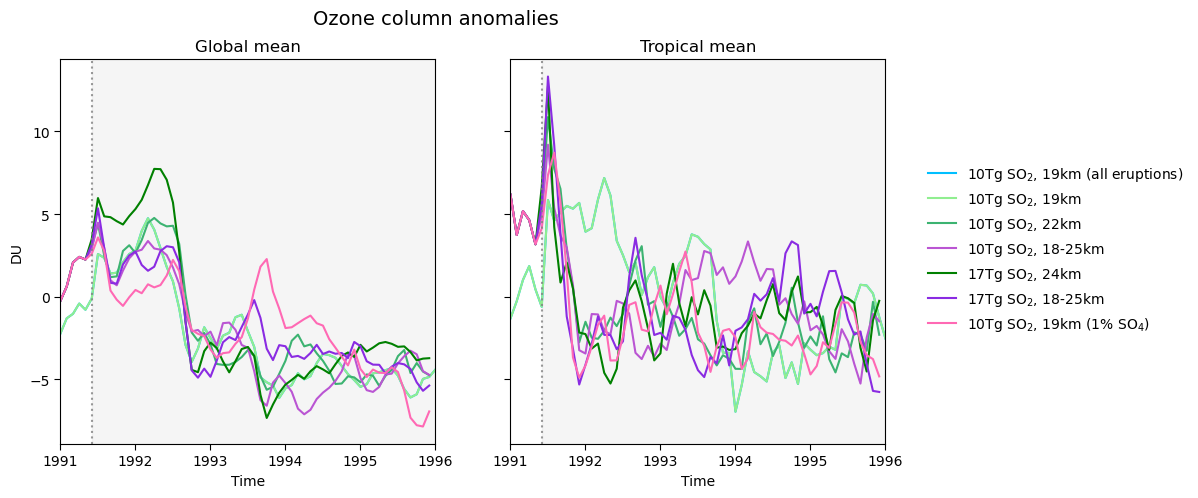

In [113]:
t_19     = [t.year + (t.month-1)/12 for t in o3_anom.time.values]
t_19_c   = [t.year + (t.month-1)/12 for t in o3_19_c_anom.time.values]
t_22     = [t.year + (t.month-1)/12 for t in o3_22_anom.time.values]
t_1825   = [t.year + (t.month-1)/12 for t in o3_1825_anom.time.values]
t_24     = [t.year + (t.month-1)/12 for t in o3_24_anom.time.values]
t_1825_17tg   = [t.year + (t.month-1)/12 for t in o3_1825_17tg_anom.time.values]
t_1tg    = [t.year + (t.month-1)/12 for t in o3_1tg_anom.time.values]
t_1pr    = [t.year + (t.month-1)/12 for t in o3_1pr_anom.time.values]
t_60tg   = [t.year + (t.month-1)/12 for t in o3_60tg_anom.time.values]

fig, ax = plt.subplots(1, 2, figsize=(10, 5), sharey=True)
ax[0].plot(t_19, o3_anom, color = "deepskyblue", label = "10Tg SO$_2$, 19km (all eruptions)")
ax[0].plot(t_19_c, o3_19_c_anom, color = "lightgreen", label = "10Tg SO$_2$, 19km")
ax[0].plot(t_22, o3_22_anom, color = "mediumseagreen", label = "10Tg SO$_2$, 22km")
ax[0].plot(t_1825, o3_1825_anom, color = "mediumorchid", label = "10Tg SO$_2$, 18-25km")
ax[0].plot(t_24, o3_24_anom, color = "green", label = "17Tg SO$_2$, 24km")
ax[0].plot(t_1825_17tg, o3_1825_17tg_anom, color = "blueviolet", label = "17Tg SO$_2$, 18-25km")
#ax[0].plot(t_1tg, o3_1tg_anom, color="orange", label="1Tg SO$_2$, 19km")
ax[0].plot(t_1pr, o3_1pr_anom, color="hotpink", label="10Tg SO$_2$, 19km (1% SO$_4$)")
#ax[0].plot(t_60tg, o3_60tg_anom, color="cornflowerblue", label="60Tg SO$_2$, 19km")
ax[0].set_xlabel("Time")
ax[0].set_ylabel("DU")
ax[0].set_title("Global mean", fontsize=12)

ax[1].plot(t_19, o3_anom_trop, color = "deepskyblue", label = "10Tg SO$_2$, 19km (all eruptions)")
ax[1].plot(t_19_c, o3_19_c_anom_trop, color = "lightgreen", label =  "10Tg SO$_2$, 19km")
ax[1].plot(t_22, o3_22_anom_trop, color = "mediumseagreen", label = "10Tg SO$_2$, 22km")
ax[1].plot(t_1825, o3_1825_anom_trop, color = "mediumorchid", label = "10Tg SO$_2$, 18-25km")
ax[1].plot(t_24, o3_24_anom_trop, color = "green", label = "17Tg SO$_2$, 24km")
ax[1].plot(t_1825_17tg, o3_1825_17tg_anom_trop, color = "blueviolet", label =  "17Tg SO$_2$, 18-25km")
#ax[1].plot(t_1tg, o3_1tg_anom_trop, color="orange", label="1Tg SO$_2$, 19km")
ax[1].plot(t_1pr, o3_1pr_anom_trop, color="hotpink", label="10Tg SO$_2$, 19km (1% SO$_4$)")
#ax[1].plot(t_60tg, o3_60tg_anom_trop, color="cornflowerblue", label="60Tg SO$_2$, 19km")
ax[1].set_xlabel("Time")
ax[1].set_title("Tropical mean", fontsize=12)

eruption_float = 1991 + (6-1)/12  
end_float = 1996 + (1-1)/12     

for i, a in enumerate(ax):
    a.axvline(eruption_float, color='gray', ls=":", alpha=0.8)
    a.axvspan(eruption_float, end_float, color='gray', alpha=0.08, zorder=0)
    
    a.tick_params(direction='out', length=4)

    a.set_xticks([1991, 1992, 1993, 1994, 1995, 1996])
    a.set_xticklabels(["1991", "1992", "1993", "1994", "1995", "1996"])
    
    
    a.set_xlim(1991, 1996)
    
handles, labels = ax[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="center left",
    bbox_to_anchor=(0.98, 0.5),
    frameon=False
)

fig.suptitle("Ozone column anomalies", fontsize=14)
fig.subplots_adjust(right=0.95)
plt.show()

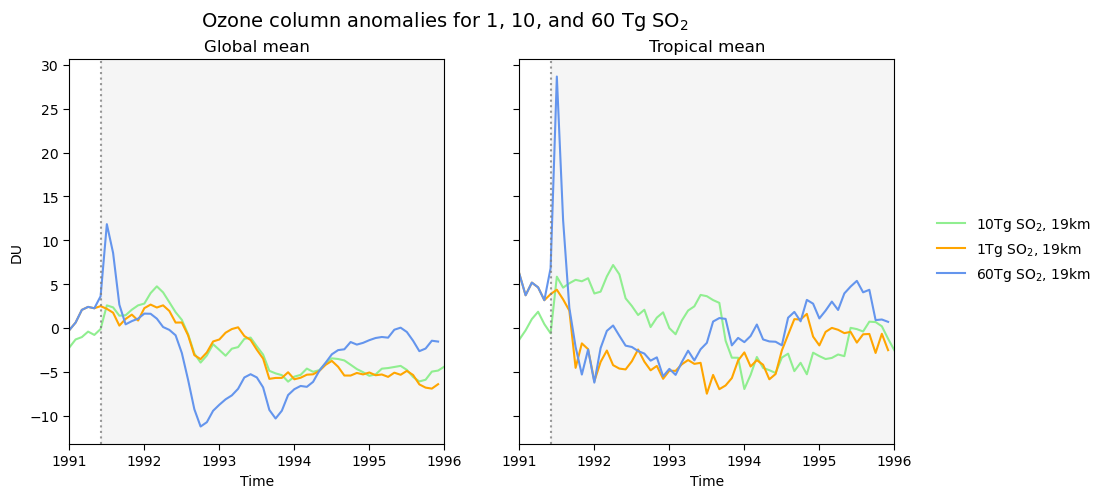

In [112]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5), sharey=True)
ax[0].plot(t_19_c, o3_19_c_anom, color = "lightgreen", label = "10Tg SO$_2$, 19km")
ax[0].plot(t_1tg, o3_1tg_anom, color="orange", label="1Tg SO$_2$, 19km")
ax[0].plot(t_60tg, o3_60tg_anom, color="cornflowerblue", label="60Tg SO$_2$, 19km")
ax[0].set_xlabel("Time")
ax[0].set_ylabel("DU")
ax[0].set_title("Global mean", fontsize=12)

ax[1].plot(t_19_c, o3_19_c_anom_trop, color = "lightgreen", label =  "10Tg SO$_2$, 19km")
ax[1].plot(t_1tg, o3_1tg_anom_trop, color="orange", label="1Tg SO$_2$, 19km")
ax[1].plot(t_60tg, o3_60tg_anom_trop, color="cornflowerblue", label="60Tg SO$_2$, 19km")
ax[1].set_xlabel("Time")
ax[1].set_title("Tropical mean", fontsize=12)

eruption_float = 1991 + (6-1)/12  
end_float = 1996 + (1-1)/12     

for i, a in enumerate(ax):
    a.axvline(eruption_float, color='gray', ls=":", alpha=0.8)
    a.axvspan(eruption_float, end_float, color='gray', alpha=0.08, zorder=0)
    
    a.tick_params(direction='out', length=4)

    a.set_xticks([1991, 1992, 1993, 1994, 1995, 1996])
    a.set_xticklabels(["1991", "1992", "1993", "1994", "1995", "1996"])
    
    
    a.set_xlim(1991, 1996)
    
handles, labels = ax[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="center left",
    bbox_to_anchor=(0.98, 0.5),
    frameon=False
)

fig.suptitle("Ozone column anomalies for 1, 10, and 60 Tg SO$_2$", fontsize=14)
fig.subplots_adjust(right=0.95)
plt.show()

In [117]:
def get_total_du(ds, lat_range=None):
    var = "cb_O3"
    data = ds[var].sel(lat=slice(*lat_range)) if lat_range else ds[var]
    weights = np.cos(np.deg2rad(data.lat))
    return data.weighted(weights).mean(dim=["lat", "lon"]) * DU

o3 = get_total_du(ds_19)
o3_19_c = get_total_du(ds_19_c)
o3_22 = get_total_du(ds_22)
o3_1825 = get_total_du(ds_1825)
o3_24 = get_total_du(ds_24)
o3_1825_17tg = get_total_du(ds_1825_17tg)
o3_1pr = get_total_du(ds_1pr)
o3_1tg = get_total_du(ds_1tg)
o3_60tg = get_total_du(ds_60tg)

o3_trop = get_total_du(ds_19, lat_range=(-20, 20))
o3_19_c_trop = get_total_du(ds_19_c, lat_range=(-20, 20))
o3_22_trop = get_total_du(ds_22, lat_range=(-20, 20))
o3_1825_trop = get_total_du(ds_1825, lat_range=(-20, 20))
o3_24_trop = get_total_du(ds_24, lat_range=(-20, 20))
o3_1825_17tg_trop = get_total_du(ds_1825_17tg, lat_range=(-20, 20))
o3_1pr_trop = get_total_du(ds_1pr, lat_range=(-20, 20))
o3_1tg_trop = get_total_du(ds_1tg, lat_range=(-20,20))
o3_60tg_trop = get_total_du(ds_60tg, lat_range=(-20,20))

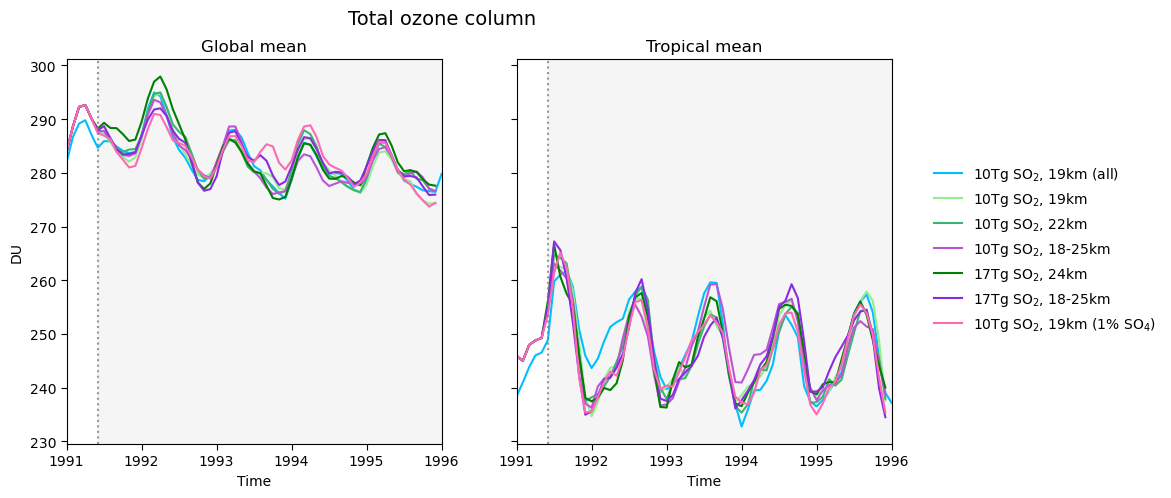

In [124]:
o3 = o3.sel(time=slice('1991-01-01', '1996-01-01'))
o3_trop = o3_trop.sel(time=slice("1991-01-01", "1996-01-01"))
def to_float(x):
    return [t.year + (t.month-1)/12 for t in x.time.values]

fig, ax = plt.subplots(1, 2, figsize=(10, 5), sharey=True)

ax[0].plot(to_float(o3), o3, color="deepskyblue", label="10Tg SO$_2$, 19km (all)")
ax[0].plot(to_float(o3_19_c), o3_19_c, color="lightgreen", label="10Tg SO$_2$, 19km")
ax[0].plot(to_float(o3_22), o3_22, color="mediumseagreen", label="10Tg SO$_2$, 22km")
ax[0].plot(to_float(o3_1825), o3_1825, color="mediumorchid", label="10Tg SO$_2$, 18-25km")
ax[0].plot(to_float(o3_24), o3_24, color="green", label="17Tg SO$_2$, 24km")
ax[0].plot(to_float(o3_1825_17tg), o3_1825_17tg, color="blueviolet", label="17Tg SO$_2$, 18-25km")
#ax[0].plot(to_float(o3_1tg), o3_1tg, color="orange", label="1Tg SO$_2$, 19km")
ax[0].plot(to_float(o3_1pr), o3_1pr, color="hotpink", label="10Tg SO$_2$, 19km (1% SO$_4$)")
#ax[0].plot(to_float(o3_60tg), o3_60tg, color="cornflowerblue", label="60Tg SO$_2$, 19km")
ax[0].set_ylabel("DU")
ax[0].set_xlabel("Time")
ax[0].set_title("Global mean")

ax[1].plot(to_float(o3_trop), o3_trop, color="deepskyblue")
ax[1].plot(to_float(o3_19_c_trop), o3_19_c_trop, color="lightgreen")
ax[1].plot(to_float(o3_22_trop), o3_22_trop, color="mediumseagreen")
ax[1].plot(to_float(o3_1825_trop), o3_1825_trop, color="mediumorchid")
ax[1].plot(to_float(o3_24_trop), o3_24_trop, color="green")
ax[1].plot(to_float(o3_1825_17tg_trop), o3_1825_17tg_trop, color="blueviolet")
#ax[1].plot(to_float(o3_1tg_trop), o3_1tg_trop, color="orange")
ax[1].plot(to_float(o3_1pr_trop), o3_1pr_trop, color="hotpink")
#ax[1].plot(to_float(o3_60tg_trop), o3_60tg_trop, color="cornflowerblue")
ax[1].set_xlabel("Time")
ax[1].set_title("Tropical mean")

eruption_float = 1991 + (6-1)/12  
end_float = 1996 + (1-1)/12     

for i, a in enumerate(ax):
    a.axvline(eruption_float, color='gray', ls=":", alpha=0.8)
    a.axvspan(eruption_float, end_float, color='gray', alpha=0.08, zorder=0)
    
    a.tick_params(direction='out', length=4)

    a.set_xticks([1991, 1992, 1993, 1994, 1995, 1996])
    a.set_xticklabels(["1991", "1992", "1993", "1994", "1995", "1996"])
    
    a.set_xlim(1991, 1996)

handles, labels = ax[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="center left",
    bbox_to_anchor=(0.98, 0.5),
    frameon=False
)


fig.suptitle("Total ozone column", fontsize=14)
fig.subplots_adjust(right=0.95)
plt.show()

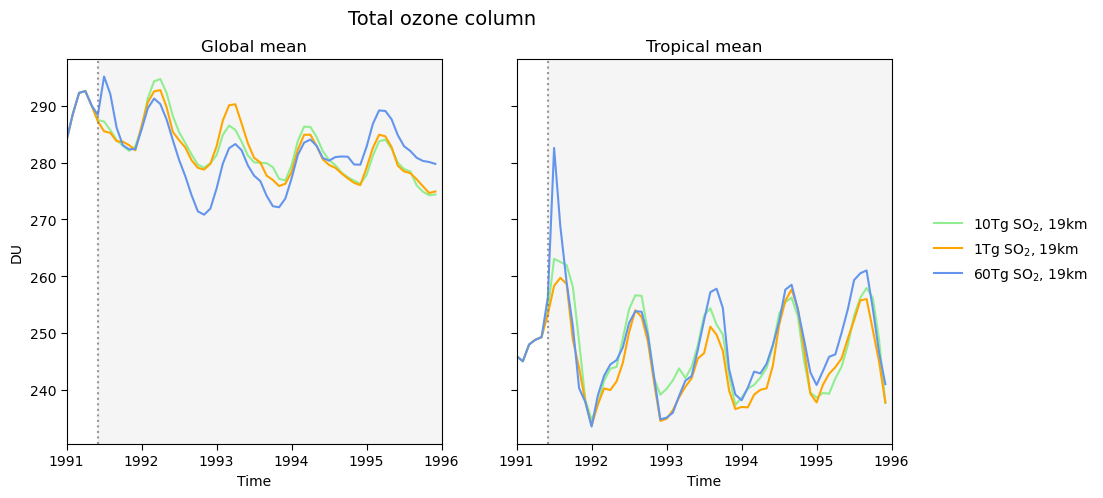

In [125]:
o3 = o3.sel(time=slice('1991-01-01', '1996-01-01'))
o3_trop = o3_trop.sel(time=slice("1991-01-01", "1996-01-01"))
eruption_date=cftime.DatetimeNoLeap(1991, 6, 1)

fig, ax = plt.subplots(1, 2, figsize=(10, 5), sharey=True)
ax[0].plot(to_float(o3_19_c), o3_19_c, color="lightgreen", label="10Tg SO$_2$, 19km")
ax[0].plot(to_float(o3_1tg), o3_1tg, color="orange", label="1Tg SO$_2$, 19km")
ax[0].plot(to_float(o3_60tg), o3_60tg, color="cornflowerblue", label="60Tg SO$_2$, 19km")
ax[0].set_xlabel("Time")
ax[0].set_ylabel("DU")
ax[0].set_title("Global mean", fontsize=12)

ax[1].plot(to_float(o3_19_c_trop), o3_19_c_trop, color="lightgreen")
ax[1].plot(to_float(o3_1tg_trop), o3_1tg_trop, color="orange")
ax[1].plot(to_float(o3_60tg_trop), o3_60tg_trop, color="cornflowerblue")
ax[1].set_xlabel("Time")
ax[1].set_title("Tropical mean", fontsize=12)

eruption_float = 1991 + (6-1)/12  
end_float = 1996 + (1-1)/12     

for i, a in enumerate(ax):
    a.axvline(eruption_float, color='gray', ls=":", alpha=0.8)
    a.axvspan(eruption_float, end_float, color='gray', alpha=0.08, zorder=0)
    
    a.tick_params(direction='out', length=4)

    a.set_xticks([1991, 1992, 1993, 1994, 1995, 1996])
    a.set_xticklabels(["1991", "1992", "1993", "1994", "1995", "1996"])
    
    a.set_xlim(1991, 1996)

handles, labels = ax[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="center left",
    bbox_to_anchor=(0.98, 0.5),
    frameon=False
)


fig.suptitle("Total ozone column", fontsize=14)
fig.subplots_adjust(right=0.95)
plt.show()

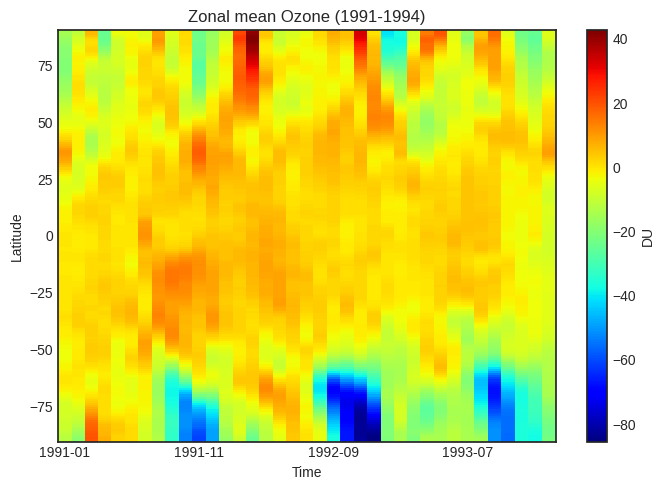

In [153]:
o3_cb = ds_19[cb_o3]
baseline = o3_cb.sel(time=slice("1975-01", "1990-12"))
base = baseline.groupby("time.month").mean("time")
o3_anom = o3_cb.groupby("time.month") - base

o3_zoom= o3_anom.sel(time=slice('1991-01-01', '1994-01-01'))
o3_mean = o3_zoom.mean(dim="lon") * DU
lat_o3 = o3_mean["lat"]
time_o3 = o3_zoom["time"].values

plt.figure(figsize=(7,5))
ax = plt.subplot()
pc = ax.pcolormesh(
    time_o3,
    lat_o3,
    o3_mean.T, 
    shading="auto",  
    cmap="jet"
)
plt.colorbar(pc, ax=ax, label="DU")
ax.set_xlabel("Time")
ax.set_ylabel("Latitude")
ax.set_title("Zonal mean Ozone (1991-1994)")
plt.tight_layout()
plt.show()

In [143]:
o3_cb = ds_19[cb_o3].mean(dim="lon")
baseline = o3_cb.sel(time=slice("1975-01", "1990-12"))
base = baseline.groupby("time.month").mean("time")

In [144]:
def plot_o3_panel(ds, base, ax, title, plot_period=("1991-01-01", "1995-12-31")):
    o3_zonal = ds["cb_O3"].mean(dim="lon")
    o3_anom = (o3_zonal.groupby("time.month") - base) *DU
    o3_sel = o3_anom.sel(time=slice(*plot_period))

    norm = TwoSlopeNorm(vcenter=0, vmin=-80, vmax=30) 

    im = o3_sel.T.plot.pcolormesh(
        ax=ax, 
        x="time", 
        y="lat",
        cmap="PiYG_r", 
        norm=norm,
        add_colorbar=False, 
        shading="auto" 
    )

    ax.set_title(title, fontsize=12,  pad=10)
    ax.set_xlabel("") 
    ax.set_ylabel("")

    ax.plot(cftime.DatetimeNoLeap(1991, 6, 1), 15, marker="^",
            color="red", markersize=9, zorder=5)

    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.set_title(title, fontsize=12)
    
    return im

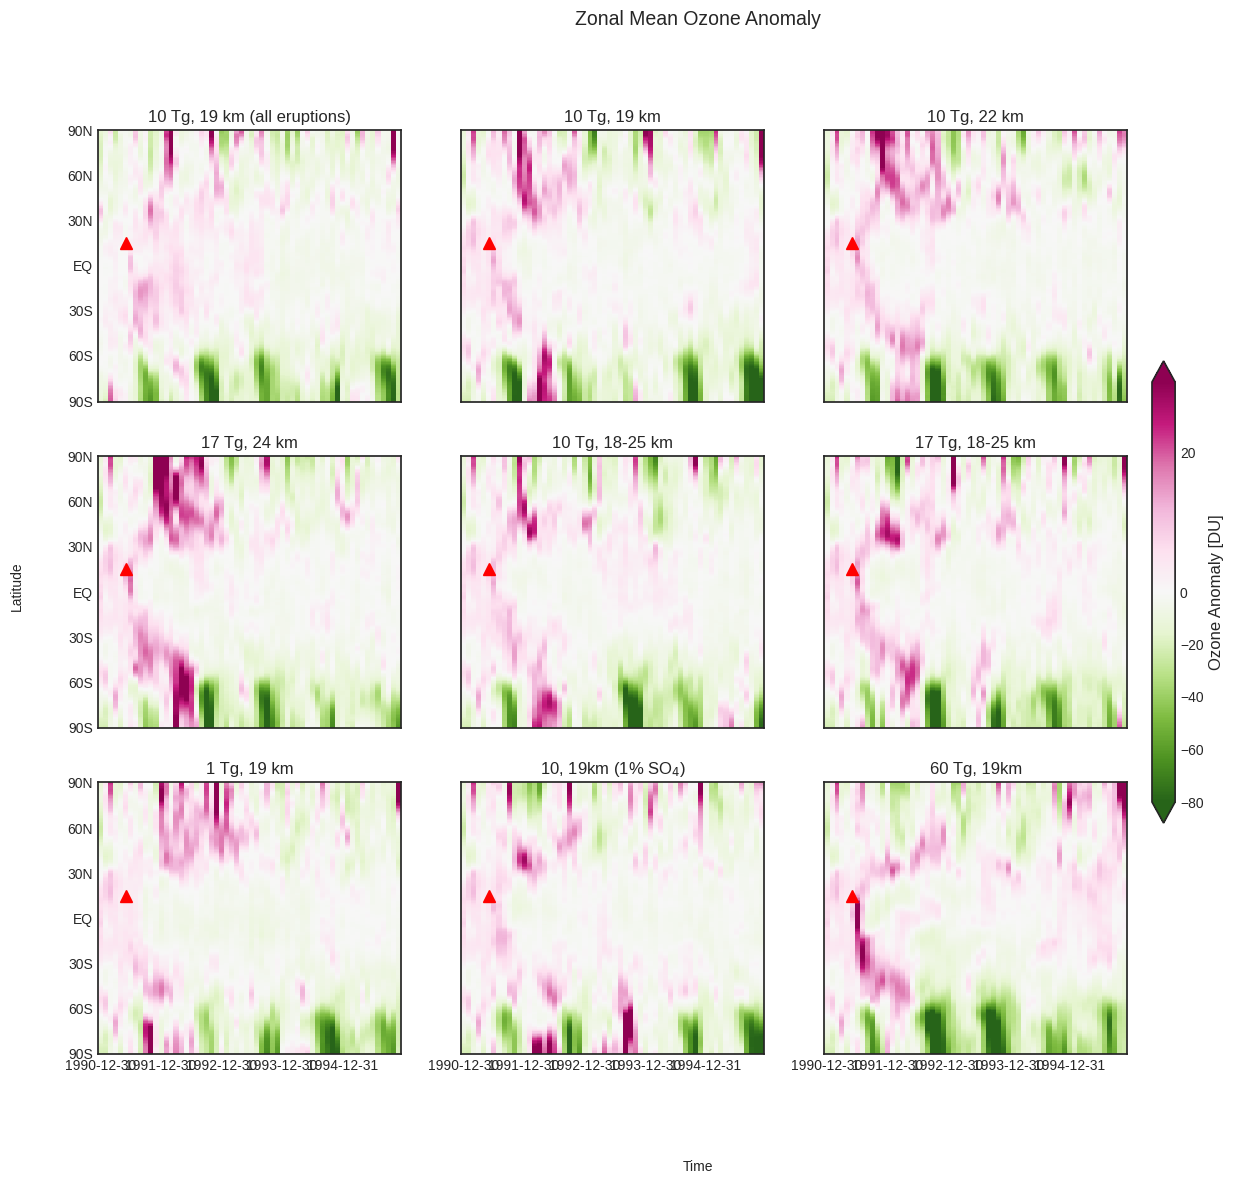

In [145]:
datasets = [ds_19, ds_19_c, ds_22, ds_24, ds_1825, ds_1825_17tg, ds_1tg, ds_1pr, ds_60tg]
titles = [
    "10 Tg, 19 km (all eruptions)",
    "10 Tg, 19 km",
    "10 Tg, 22 km",
    "17 Tg, 24 km",
    "10 Tg, 18-25 km",
    "17 Tg, 18-25 km",
    "1 Tg, 19 km",
    "10, 19km (1% SO$_4$)",
    "60 Tg, 19km"
]

fig, axs = plt.subplots(3, 3, figsize=(16, 12), sharex=True, sharey=True)

for i, (ax, ds, title) in enumerate(zip(axs.flat, datasets, titles)):
    im = plot_o3_panel(ds, base, ax=ax, title=title)

axs[0, 0].set_yticks([-90, -60, -30, 0, 30, 60, 90])
axs[0, 0].set_yticklabels(["90S", "60S", "30S", "EQ", "30N", "60N", "90N"])


cbar = fig.colorbar(im, ax=axs, location='right', shrink=0.5, pad=0.02, extend='both')
cbar.set_label("Ozone Anomaly [DU]", fontsize=12)

fig.supxlabel('Time', fontsize=10)
fig.supylabel('Latitude', fontsize=10, x=0.07)
plt.suptitle("Zonal Mean Ozone Anomaly", fontsize=14, y=0.98)
plt.tight_layout
plt.show()

In [126]:
o3 = ds_19["O3"].mean(dim="lon")
baseline = o3.sel(time=slice("1975-01", "1990-12"))
base = baseline.groupby("time.month").mean("time")

In [129]:
def plot_o3_lat_time(ds,
    base_clim, title,
    plot_period=("1991-01-01", "1996-01-01"),
    lev=50,
    ax=None,
    cmap="PiYG_r",
    add_colorbar=True,
):
    o3 = ds["O3"].mean(dim="lon")
    o3_anom = o3.groupby("time.month") - base_clim
    o3_anom = o3_anom

    o3_sel = o3_anom.sel(time=slice(*plot_period))
    o3_sel = o3_sel.sel(lev=lev, method="nearest")
    o3_lat_time = o3_sel

    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 5))

    p = o3_lat_time.T.plot(
        ax=ax,
        x="time",
        y="lat",
        cmap=cmap,
        add_colorbar=add_colorbar,
        cbar_kwargs={"label": "Ozone anomaly [mol/mol]"} if add_colorbar else None,
    )

    ax.plot(cftime.DatetimeNoLeap(1991, 6, 1), 15, marker="^",
            color="red", markersize=9, zorder=5)

    ax.set_title(title, fontsize=12,  pad=10)
    ax.set_xlabel("") 
    ax.set_ylabel("")

    ax.plot(cftime.DatetimeNoLeap(1991, 6, 1), 15, marker="^",
            color="red", markersize=9, zorder=5)

    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.set_title(title, fontsize=12)

    return ax

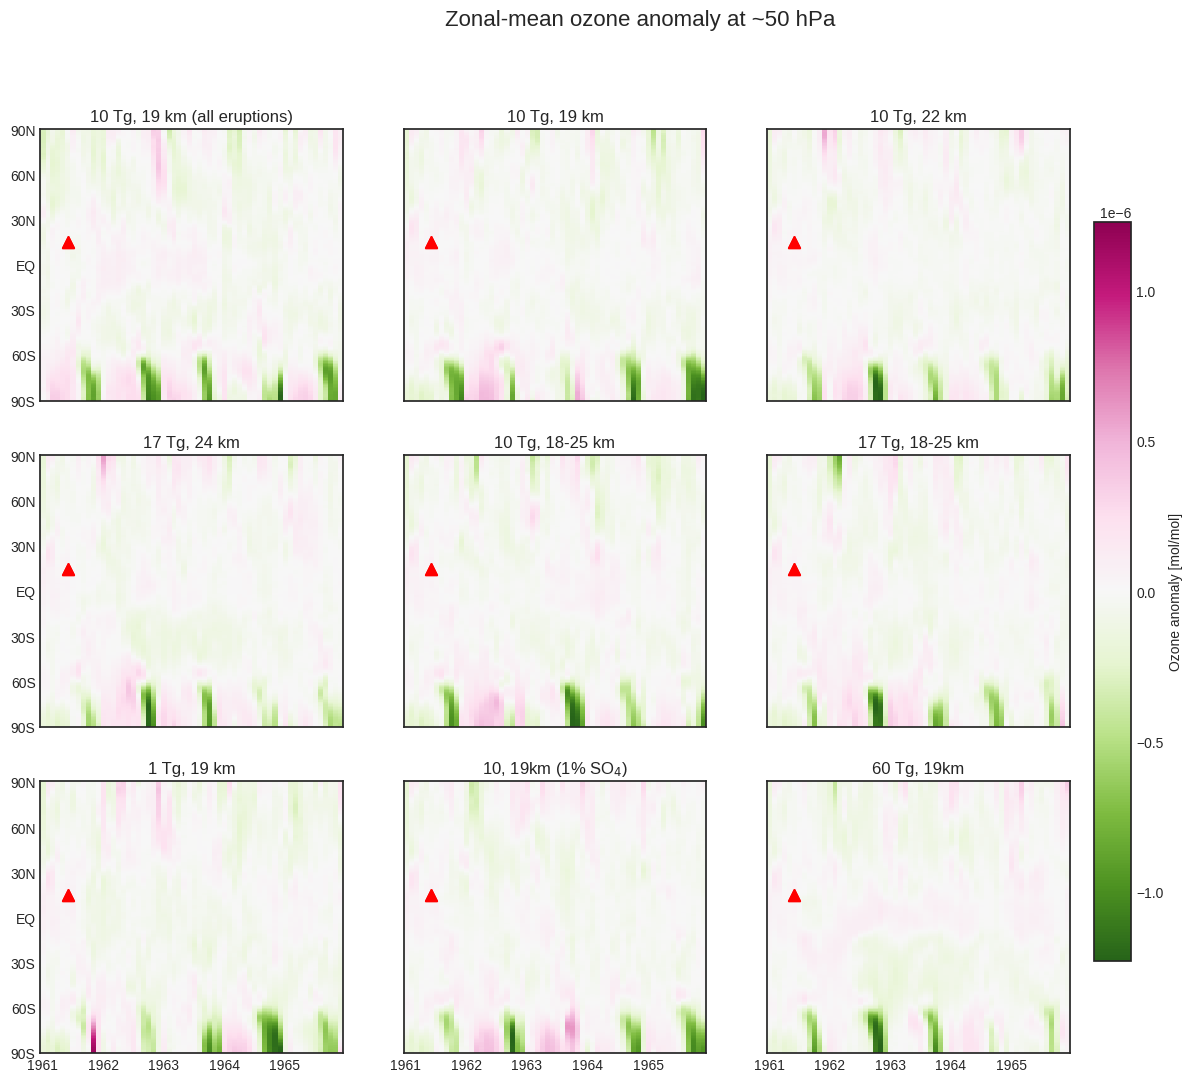

In [131]:
fig, axs = plt.subplots(3, 3, figsize=(16, 12), sharex=True, sharey=True)

for ax, ds, title in zip(axs.flat, datasets, titles):
    plot_o3_lat_time(
        ds,
        base, title=title,
        lev=50,
        ax=ax,
        add_colorbar=False,
    )


axs[0, 0].set_yticks([-90, -60, -30, 0, 30, 60, 90])
axs[0, 0].set_yticklabels(["90S", "60S", "30S", "EQ", "30N", "60N", "90N"])

fig.colorbar(
    axs.flat[0].collections[0],
    ax=axs,
    label="Ozone anomaly [mol/mol]",
    shrink=0.8,
    pad=0.02,
)

fig.suptitle("Zonal-mean ozone anomaly at ~50 hPa", fontsize=16)
plt.show()


In [122]:
lat_50 = ds_19.sel(lev=50, method="nearest")["lev"].values
lat_50

array(51.67749897)

<>:35: SyntaxWarning: invalid escape sequence '\c'
<>:36: SyntaxWarning: invalid escape sequence '\c'
<>:39: SyntaxWarning: invalid escape sequence '\c'
<>:35: SyntaxWarning: invalid escape sequence '\c'
<>:36: SyntaxWarning: invalid escape sequence '\c'
<>:39: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_2240904/254914387.py:35: SyntaxWarning: invalid escape sequence '\c'
  ax.set_xlabel("Latitude [$^\circ$N]", fontsize=12)
/tmp/ipykernel_2240904/254914387.py:36: SyntaxWarning: invalid escape sequence '\c'
  ax.set_title("Vertical model structure with tropopause height (80$^\circ$E)", fontsize=14)
/tmp/ipykernel_2240904/254914387.py:39: SyntaxWarning: invalid escape sequence '\c'
  plt.colorbar(im, label="Temperature [$^\circ$C]")
/tmp/ipykernel_2240904/254914387.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper right')


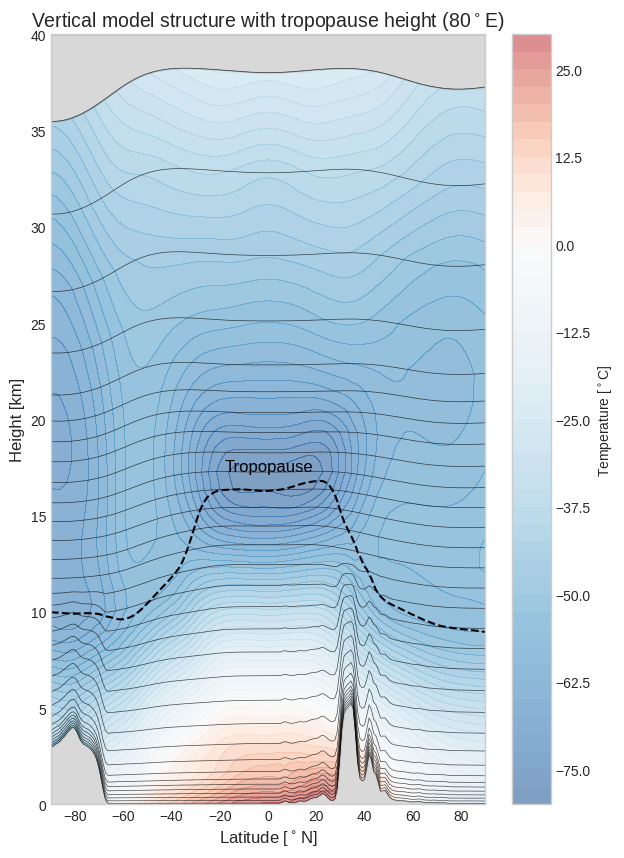

In [116]:
z_zonal = ds_1pr["Z3"].sel(lon=80)
z_zonal = z_zonal.mean(dim=["time"]) / 1000                                  # km
temp_zonal = ds_1pr["T"].sel(lon=80)
temp_zonal = temp_zonal.mean(dim=["time"]) - 272.15                              # Celsius
lats = ds_1pr.lat.values 
norm = TwoSlopeNorm(vcenter=0, vmin=-90, vmax=40) 

lats_2d, _ = np.meshgrid(lats, np.arange(len(z_zonal.lev)))                              # same length for the levels
fig, ax = plt.subplots(figsize=(7, 10))

im = ax.contourf(lats_2d, z_zonal, temp_zonal, levels=50, cmap="RdBu_r", alpha=0.55, norm=norm)

for i in range(len(z_zonal.lev)):
    y_values = z_zonal.isel(lev=i).values 
    ax.plot(lats, y_values, color='black', linewidth=0.5, alpha=0.7)

trop_z_zonal = ds_1pr["TROP_Z"].sel(lon=80)
trop_z_zonal = trop_z_zonal.mean(dim=["time"]) / 1000
ax.plot(lats, trop_z_zonal, color="black", linewidth=1.5, 
        linestyle="--")

mid_idx = len(lats) // 2
label_x = lats[mid_idx]
label_y = trop_z_zonal.isel(lat=mid_idx) + 1.0 

ax.text(label_x, label_y, "Tropopause", color="black", 
         ha="center", fontsize=12)

ax.fill_between(lats, 0, z_zonal.isel(lev=-1), color='gray', alpha=0.3)
ax.fill_between(lats, z_zonal.isel(lev=0), 40, color='gray', alpha=0.3)
ax.grid(False)
ax.set_ylim(0, 40)
ax.set_xlim(-90, 90)
ax.set_ylabel("Height [km]", fontsize=12)
ax.set_xlabel("Latitude [$^\circ$N]", fontsize=12)
ax.set_title("Vertical model structure with tropopause height (80$^\circ$E)", fontsize=14)

ax.legend(loc='upper right')
plt.colorbar(im, label="Temperature [$^\circ$C]")
plt.show()

<>:32: SyntaxWarning: invalid escape sequence '\c'
<>:36: SyntaxWarning: invalid escape sequence '\c'
<>:32: SyntaxWarning: invalid escape sequence '\c'
<>:36: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_2240904/134134090.py:32: SyntaxWarning: invalid escape sequence '\c'
  ax.set_xlabel("Latitude [$^\circ$N]", fontsize=12)
/tmp/ipykernel_2240904/134134090.py:36: SyntaxWarning: invalid escape sequence '\c'
  plt.colorbar(im, label="Temperature [$^\circ$C]")
/tmp/ipykernel_2240904/134134090.py:35: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper right')


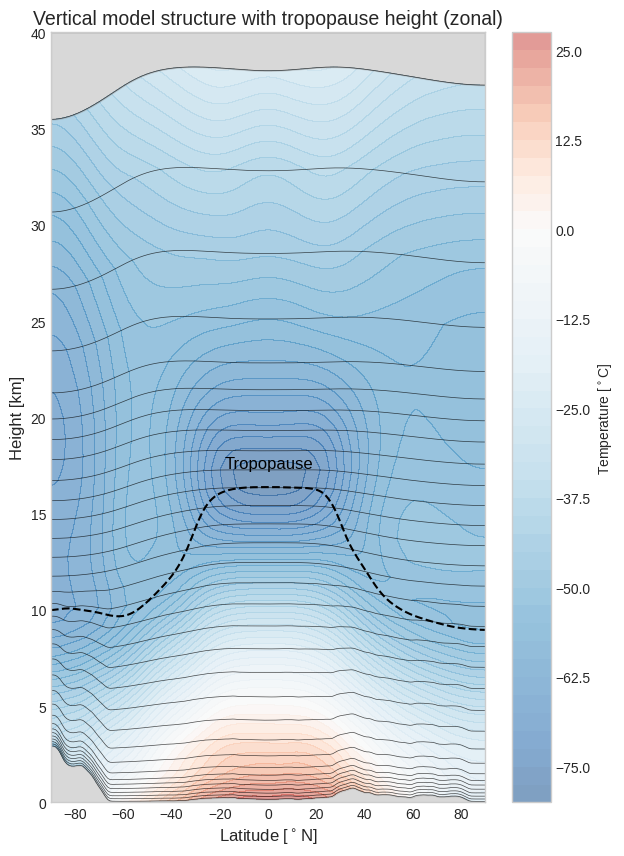

In [115]:
z_zonal = ds_1pr["Z3"].mean(dim=["time", "lon"]) / 1000                                  # km
temp_zonal = ds_1pr["T"].mean(dim=["time", "lon"]) - 272.15                              # Celsius
lats = ds_1pr.lat.values 
norm = TwoSlopeNorm(vcenter=0, vmin=-90, vmax=40) 

lats_2d, _ = np.meshgrid(lats, np.arange(len(z_zonal.lev)))                              # same length for the levels
fig, ax = plt.subplots(figsize=(7, 10))

im = ax.contourf(lats_2d, z_zonal, temp_zonal, levels=50, cmap="RdBu_r", alpha=0.55, norm=norm)

for i in range(len(z_zonal.lev)):
    y_values = z_zonal.isel(lev=i).values 
    ax.plot(lats, y_values, color='black', linewidth=0.5, alpha=0.7)

trop_z_zonal = ds_1pr["TROP_Z"].mean(dim=["time", "lon"]) / 1000
ax.plot(lats, trop_z_zonal, color="black", linewidth=1.5, 
        linestyle="--")

mid_idx = len(lats) // 2
label_x = lats[mid_idx]
label_y = trop_z_zonal.isel(lat=mid_idx) + 1.0 

ax.text(label_x, label_y, "Tropopause", color="black", 
         ha="center", fontsize=12)

ax.fill_between(lats, 0, z_zonal.isel(lev=-1), color='gray', alpha=0.3)
ax.fill_between(lats, z_zonal.isel(lev=0), 40, color='gray', alpha=0.3)
ax.grid(False)
ax.set_ylim(0, 40)
ax.set_xlim(-90, 90)
ax.set_ylabel("Height [km]", fontsize=12)
ax.set_xlabel("Latitude [$^\circ$N]", fontsize=12)
ax.set_title("Vertical model structure with tropopause height (zonal)", fontsize=14)

ax.legend(loc='upper right')
plt.colorbar(im, label="Temperature [$^\circ$C]")
plt.show()